<a href="https://colab.research.google.com/github/ayushprsingh/GAN-Image-Deblurring/blob/main/GAN_Image_Deblurring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
!pip install -q torchmetrics scikit-image matplotlib tqdm

import os
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image, ImageFilter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision
import torchvision.transforms as transforms
from torchvision.utils import save_image

from tqdm import tqdm

from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [7]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

print("Dataset size:", len(dataset))

100%|██████████| 170M/170M [00:23<00:00, 7.23MB/s]


Dataset size: 50000


In [10]:
def create_motion_blur(image, kernel_size=9):
    """
    Creates simple horizontal motion blur.
    """

    image = image.clamp(0, 1)

    kernel = torch.zeros(
        (1, 1, kernel_size, kernel_size),
        device=image.device
    )

    kernel[0, 0, kernel_size // 2, :] = 1.0 / kernel_size

    channels = image.shape[0]

    kernel = kernel.repeat(channels, 1, 1, 1)

    image = image.unsqueeze(0)

    blurred = torch.nn.functional.conv2d(
        image,
        kernel,
        padding=kernel_size // 2,
        groups=channels
    )

    return blurred.squeeze(0).clamp(0, 1)

In [11]:
class DeblurDataset(Dataset):

    def __init__(self, base_dataset):
        self.base_dataset = base_dataset

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, index):

        sharp, _ = self.base_dataset[index]

        # Random blur size
        kernel_size = random.choice([5, 7, 9])

        blurred = create_motion_blur(
            sharp,
            kernel_size
        )

        return blurred, sharp


deblur_dataset = DeblurDataset(dataset)

loader = DataLoader(
    deblur_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print("Dataloader ready")

Dataloader ready


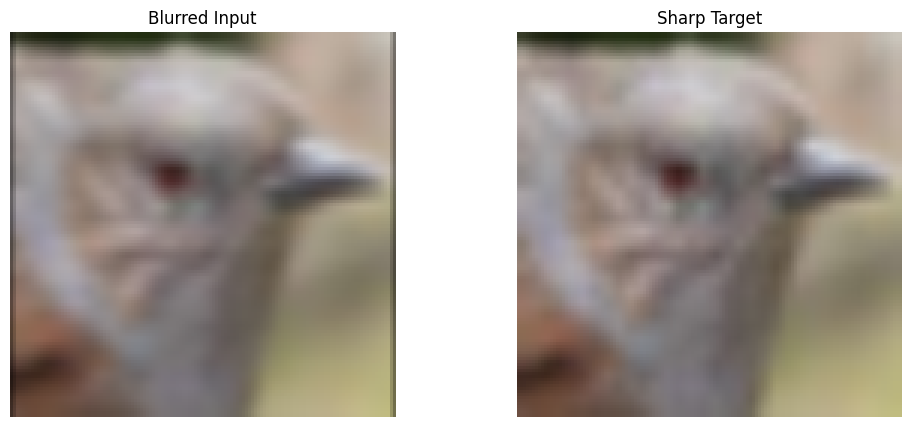

In [12]:
blurred, sharp = next(iter(loader))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(blurred[0].permute(1, 2, 0))
plt.title("Blurred Input")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sharp[0].permute(1, 2, 0))
plt.title("Sharp Target")
plt.axis("off")

plt.show()


In [14]:
class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(

            nn.Conv2d(3, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 512, 4, 2, 1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True)
        )

        # Decoder
        self.decoder = nn.Sequential(

            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(64, 3, 4, 2, 1),
            nn.Sigmoid()
        )

    def forward(self, x):

        x = self.encoder(x)
        x = self.decoder(x)

        return x


In [15]:
class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            nn.Conv2d(3, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, 4, 2, 1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512, 1, 4, 1, 1)
        )

    def forward(self, x):
        return self.model(x)

In [16]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)

print("Generator initialized successfully!")
print("Discriminator initialized successfully!")

print("Generator parameters:",
      sum(p.numel() for p in generator.parameters()))

print("Discriminator parameters:",
      sum(p.numel() for p in discriminator.parameters()))

Generator initialized successfully!
Discriminator initialized successfully!
Generator parameters: 5515395
Discriminator parameters: 2766529


In [17]:
# Loss Functions

adversarial_loss = nn.BCEWithLogitsLoss()
reconstruction_loss = nn.L1Loss()

print("Loss functions initialized.")

Loss functions initialized.


In [18]:
# Optimizers

optimizer_G = optim.Adam(
    generator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

optimizer_D = optim.Adam(
    discriminator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

print("Generator optimizer:", optimizer_G)
print("Discriminator optimizer:", optimizer_D)

Generator optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.5, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0002
    maximize: False
    weight_decay: 0
)
Discriminator optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.5, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0002
    maximize: False
    weight_decay: 0
)


In [19]:
# Quick GAN Training Test

EPOCHS = 1
MAX_BATCHES = 50

G_losses = []
D_losses = []

generator.train()
discriminator.train()

for epoch in range(EPOCHS):

    epoch_G_loss = 0
    epoch_D_loss = 0

    progress = tqdm(
        loader,
        desc=f"Epoch {epoch + 1}/{EPOCHS}"
    )

    for batch_idx, (blurred, sharp) in enumerate(progress):

        # Stop after 50 batches for quick testing
        if batch_idx >= MAX_BATCHES:
            break

        blurred = blurred.to(device)
        sharp = sharp.to(device)

        # =========================
        # Train Discriminator
        # =========================

        optimizer_D.zero_grad()

        fake = generator(blurred)

        real_output = discriminator(sharp)
        fake_output = discriminator(fake.detach())

        real_labels = torch.ones_like(real_output)
        fake_labels = torch.zeros_like(fake_output)

        real_loss = adversarial_loss(
            real_output,
            real_labels
        )

        fake_loss = adversarial_loss(
            fake_output,
            fake_labels
        )

        D_loss = (real_loss + fake_loss) / 2

        D_loss.backward()
        optimizer_D.step()

        # =========================
        # Train Generator
        # =========================

        optimizer_G.zero_grad()

        fake = generator(blurred)

        fake_output = discriminator(fake)

        G_adv = adversarial_loss(
            fake_output,
            torch.ones_like(fake_output)
        )

        G_reconstruction = reconstruction_loss(
            fake,
            sharp
        )

        G_loss = G_adv + 100 * G_reconstruction

        G_loss.backward()
        optimizer_G.step()

        epoch_G_loss += G_loss.item()
        epoch_D_loss += D_loss.item()

        progress.set_postfix(
            G_loss=f"{G_loss.item():.4f}",
            D_loss=f"{D_loss.item():.4f}"
        )

    avg_G_loss = epoch_G_loss / MAX_BATCHES
    avg_D_loss = epoch_D_loss / MAX_BATCHES

    G_losses.append(avg_G_loss)
    D_losses.append(avg_D_loss)

    print(
        f"\nEpoch {epoch + 1} completed"
    )

    print(
        f"Average Generator Loss: {avg_G_loss:.4f}"
    )

    print(
        f"Average Discriminator Loss: {avg_D_loss:.4f}"
    )

Epoch 1/1:   2%|▏         | 50/3125 [00:06<06:36,  7.76it/s, D_loss=0.7420, G_loss=7.1098]


Epoch 1 completed
Average Generator Loss: 11.0567
Average Discriminator Loss: 0.5653


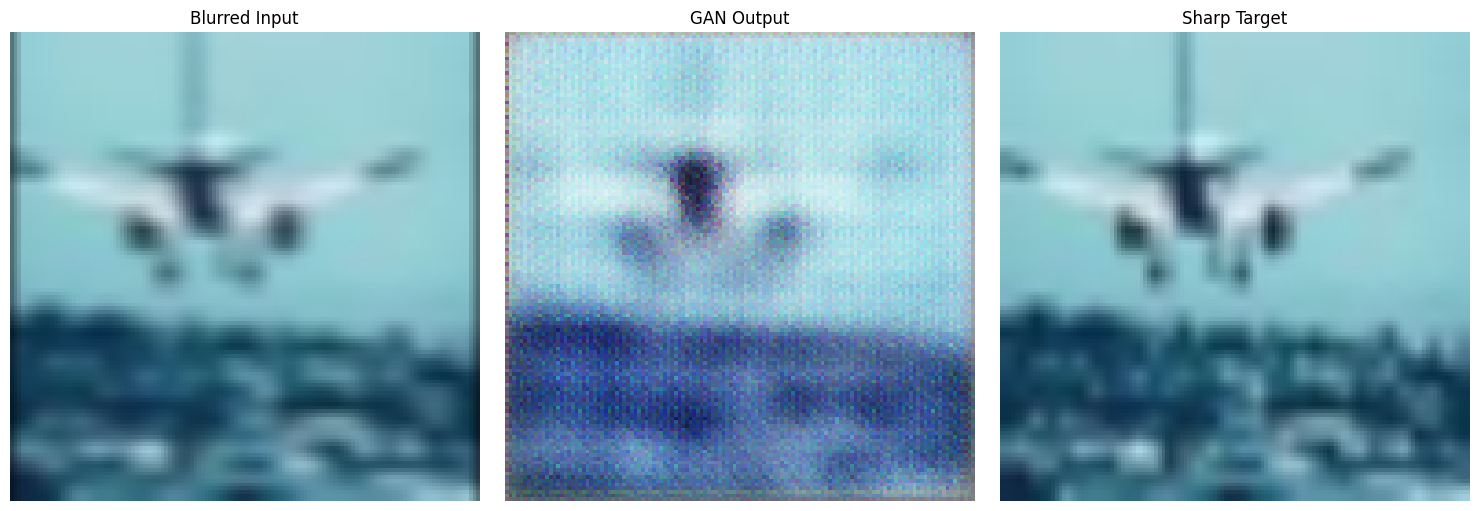

In [14]:
# Check Generator Output After Quick Test

generator.eval()

blurred, sharp = next(iter(loader))

blurred = blurred.to(device)
sharp = sharp.to(device)

with torch.no_grad():
    restored = generator(blurred)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(blurred[0].cpu().permute(1, 2, 0))
plt.title("Blurred Input")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(restored[0].cpu().permute(1, 2, 0))
plt.title("GAN Output")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(sharp[0].cpu().permute(1, 2, 0))
plt.title("Sharp Target")
plt.axis("off")

plt.tight_layout()
plt.show()

In [15]:
# Prepare training subset for the prototype

from torch.utils.data import Subset

# Use 10,000 images for the initial full prototype
train_subset = Subset(
    deblur_dataset,
    range(10000)
)

loader = DataLoader(
    train_subset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print("Training images:", len(train_subset))
print("Batches per epoch:", len(loader))

Training images: 10000
Batches per epoch: 625


In [16]:
# Full Prototype Training

EPOCHS = 5

G_losses = []
D_losses = []

os.makedirs("checkpoints", exist_ok=True)
os.makedirs("training_samples", exist_ok=True)

for epoch in range(EPOCHS):

    generator.train()
    discriminator.train()

    epoch_G_loss = 0.0
    epoch_D_loss = 0.0

    progress = tqdm(
        loader,
        desc=f"Epoch {epoch + 1}/{EPOCHS}"
    )

    for blurred, sharp in progress:

        blurred = blurred.to(device, non_blocking=True)
        sharp = sharp.to(device, non_blocking=True)

        # =====================================
        # Train Discriminator
        # =====================================

        optimizer_D.zero_grad()

        fake = generator(blurred)

        real_output = discriminator(sharp)
        fake_output = discriminator(fake.detach())

        real_labels = torch.ones_like(real_output)
        fake_labels = torch.zeros_like(fake_output)

        real_loss = adversarial_loss(
            real_output,
            real_labels
        )

        fake_loss = adversarial_loss(
            fake_output,
            fake_labels
        )

        D_loss = (real_loss + fake_loss) / 2

        D_loss.backward()
        optimizer_D.step()

        # =====================================
        # Train Generator
        # =====================================

        optimizer_G.zero_grad()

        fake = generator(blurred)

        fake_output = discriminator(fake)

        G_adv = adversarial_loss(
            fake_output,
            torch.ones_like(fake_output)
        )

        G_reconstruction = reconstruction_loss(
            fake,
            sharp
        )

        G_loss = G_adv + 100 * G_reconstruction

        G_loss.backward()
        optimizer_G.step()

        epoch_G_loss += G_loss.item()
        epoch_D_loss += D_loss.item()

        progress.set_postfix(
            G=f"{G_loss.item():.3f}",
            D=f"{D_loss.item():.3f}"
        )

    # Average losses
    avg_G = epoch_G_loss / len(loader)
    avg_D = epoch_D_loss / len(loader)

    G_losses.append(avg_G)
    D_losses.append(avg_D)

    # =====================================
    # Save checkpoint
    # =====================================

    torch.save(
        generator.state_dict(),
        f"checkpoints/generator_epoch_{epoch+1}.pth"
    )

    torch.save(
        discriminator.state_dict(),
        f"checkpoints/discriminator_epoch_{epoch+1}.pth"
    )

    # =====================================
    # Generate sample result
    # =====================================

    generator.eval()

    with torch.no_grad():
        sample_blurred, sample_sharp = next(iter(loader))

        sample_blurred = sample_blurred.to(device)

        sample_restored = generator(sample_blurred)

    # Save first sample
    save_image(
        sample_blurred[0],
        f"training_samples/epoch_{epoch+1}_blurred.png"
    )

    save_image(
        sample_restored[0],
        f"training_samples/epoch_{epoch+1}_restored.png"
    )

    save_image(
        sample_sharp[0],
        f"training_samples/epoch_{epoch+1}_sharp.png"
    )

    print(
        f"\nEpoch {epoch+1}/{EPOCHS} completed"
    )

    print(
        f"Generator Loss: {avg_G:.4f}"
    )

    print(
        f"Discriminator Loss: {avg_D:.4f}"
    )

Epoch 1/5: 100%|██████████| 625/625 [00:57<00:00, 10.92it/s, D=1.197, G=6.925]



Epoch 1/5 completed
Generator Loss: 5.7459
Discriminator Loss: 0.5999


Epoch 2/5: 100%|██████████| 625/625 [00:59<00:00, 10.51it/s, D=0.626, G=4.273]



Epoch 2/5 completed
Generator Loss: 6.6068
Discriminator Loss: 0.3888


Epoch 3/5: 100%|██████████| 625/625 [01:00<00:00, 10.27it/s, D=0.018, G=7.474]



Epoch 3/5 completed
Generator Loss: 6.6096
Discriminator Loss: 0.3854


Epoch 4/5: 100%|██████████| 625/625 [01:01<00:00, 10.09it/s, D=0.006, G=8.967]



Epoch 4/5 completed
Generator Loss: 5.9974
Discriminator Loss: 0.4062


Epoch 5/5: 100%|██████████| 625/625 [01:02<00:00, 10.03it/s, D=0.003, G=10.676]



Epoch 5/5 completed
Generator Loss: 8.7410
Discriminator Loss: 0.1183


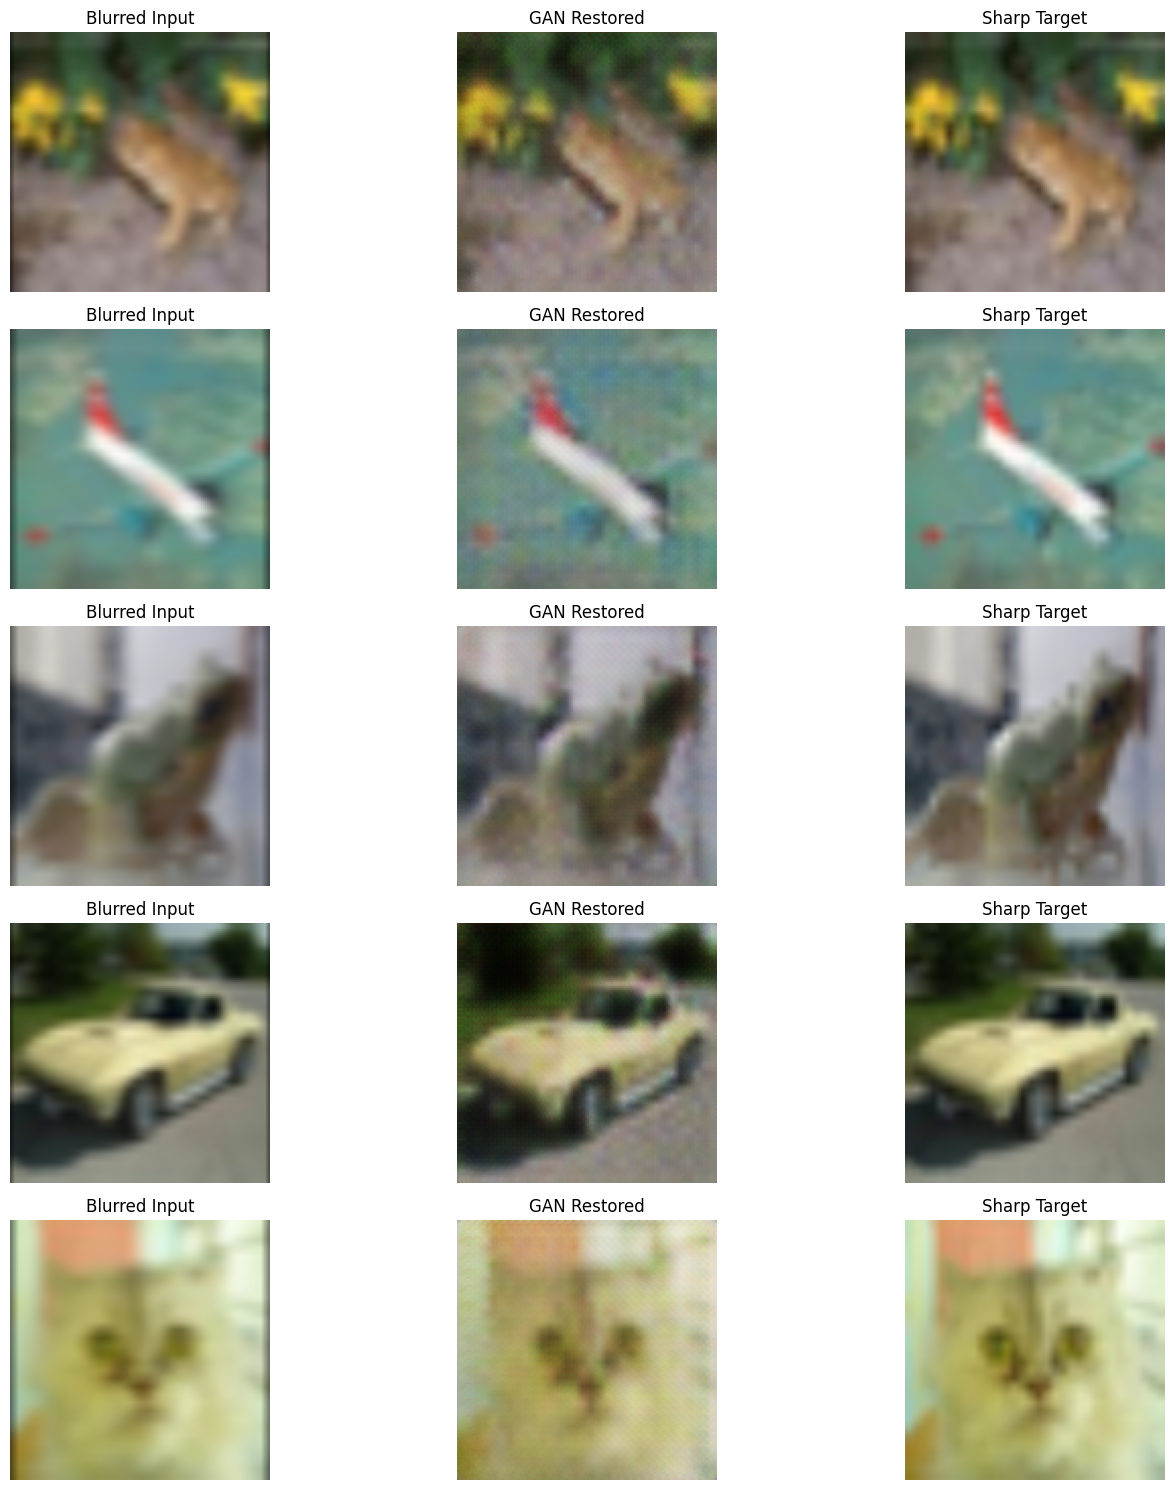

In [17]:
# ============================================
# FINAL VISUAL RESULTS
# ============================================

generator.eval()

# Get a fresh batch
blurred, sharp = next(iter(loader))

blurred = blurred.to(device)
sharp = sharp.to(device)

with torch.no_grad():
    restored = generator(blurred)

# Display 5 examples
plt.figure(figsize=(15, 15))

for i in range(5):

    # Blurred
    plt.subplot(5, 3, i * 3 + 1)
    plt.imshow(
        blurred[i].cpu().permute(1, 2, 0).clamp(0, 1)
    )
    plt.title("Blurred Input")
    plt.axis("off")

    # GAN output
    plt.subplot(5, 3, i * 3 + 2)
    plt.imshow(
        restored[i].cpu().permute(1, 2, 0).clamp(0, 1)
    )
    plt.title("GAN Restored")
    plt.axis("off")

    # Ground truth
    plt.subplot(5, 3, i * 3 + 3)
    plt.imshow(
        sharp[i].cpu().permute(1, 2, 0).clamp(0, 1)
    )
    plt.title("Sharp Target")
    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "final_visual_results.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
# Continue training the existing GAN

EPOCHS_MORE = 5

for epoch in range(EPOCHS_MORE):

    generator.train()
    discriminator.train()

    epoch_G_loss = 0.0
    epoch_D_loss = 0.0

    progress = tqdm(
        loader,
        desc=f"Additional Epoch {epoch + 1}/{EPOCHS_MORE}"
    )

    for blurred, sharp in progress:

        blurred = blurred.to(device, non_blocking=True)
        sharp = sharp.to(device, non_blocking=True)

        # -------------------------
        # Train Discriminator
        # -------------------------

        optimizer_D.zero_grad()

        fake = generator(blurred)

        real_output = discriminator(sharp)
        fake_output = discriminator(fake.detach())

        real_labels = torch.ones_like(real_output)
        fake_labels = torch.zeros_like(fake_output)

        real_loss = adversarial_loss(
            real_output,
            real_labels
        )

        fake_loss = adversarial_loss(
            fake_output,
            fake_labels
        )

        D_loss = (real_loss + fake_loss) / 2

        D_loss.backward()
        optimizer_D.step()

        # -------------------------
        # Train Generator
        # -------------------------

        optimizer_G.zero_grad()

        fake = generator(blurred)

        fake_output = discriminator(fake)

        G_adv = adversarial_loss(
            fake_output,
            torch.ones_like(fake_output)
        )

        G_reconstruction = reconstruction_loss(
            fake,
            sharp
        )

        G_loss = G_adv + 100 * G_reconstruction

        G_loss.backward()
        optimizer_G.step()

        epoch_G_loss += G_loss.item()
        epoch_D_loss += D_loss.item()

        progress.set_postfix(
            G=f"{G_loss.item():.3f}",
            D=f"{D_loss.item():.3f}"
        )

    avg_G = epoch_G_loss / len(loader)
    avg_D = epoch_D_loss / len(loader)

    G_losses.append(avg_G)
    D_losses.append(avg_D)

    print(
        f"\nAdditional Epoch {epoch + 1} completed"
    )
    print(f"Generator Loss: {avg_G:.4f}")
    print(f"Discriminator Loss: {avg_D:.4f}")

# Save the continued model

torch.save(
    generator.state_dict(),
    "generator_v2_10epochs.pth"
)

torch.save(
    discriminator.state_dict(),
    "discriminator_v2_10epochs.pth"
)

print("\n10-epoch model saved successfully.")

Additional Epoch 1/5: 100%|██████████| 625/625 [00:57<00:00, 10.91it/s, D=0.610, G=3.750]



Additional Epoch 1 completed
Generator Loss: 6.3932
Discriminator Loss: 0.4551


Additional Epoch 2/5: 100%|██████████| 625/625 [00:59<00:00, 10.50it/s, D=0.006, G=8.945]



Additional Epoch 2 completed
Generator Loss: 6.2481
Discriminator Loss: 0.3373


Additional Epoch 3/5: 100%|██████████| 625/625 [01:00<00:00, 10.25it/s, D=0.614, G=4.760]



Additional Epoch 3 completed
Generator Loss: 10.1948
Discriminator Loss: 0.0314


Additional Epoch 4/5: 100%|██████████| 625/625 [01:02<00:00, 10.08it/s, D=0.267, G=5.271]



Additional Epoch 4 completed
Generator Loss: 5.9196
Discriminator Loss: 0.4091


Additional Epoch 5/5: 100%|██████████| 625/625 [01:02<00:00,  9.99it/s, D=0.002, G=10.012]


Additional Epoch 5 completed
Generator Loss: 8.8229
Discriminator Loss: 0.0759

10-epoch model saved successfully.


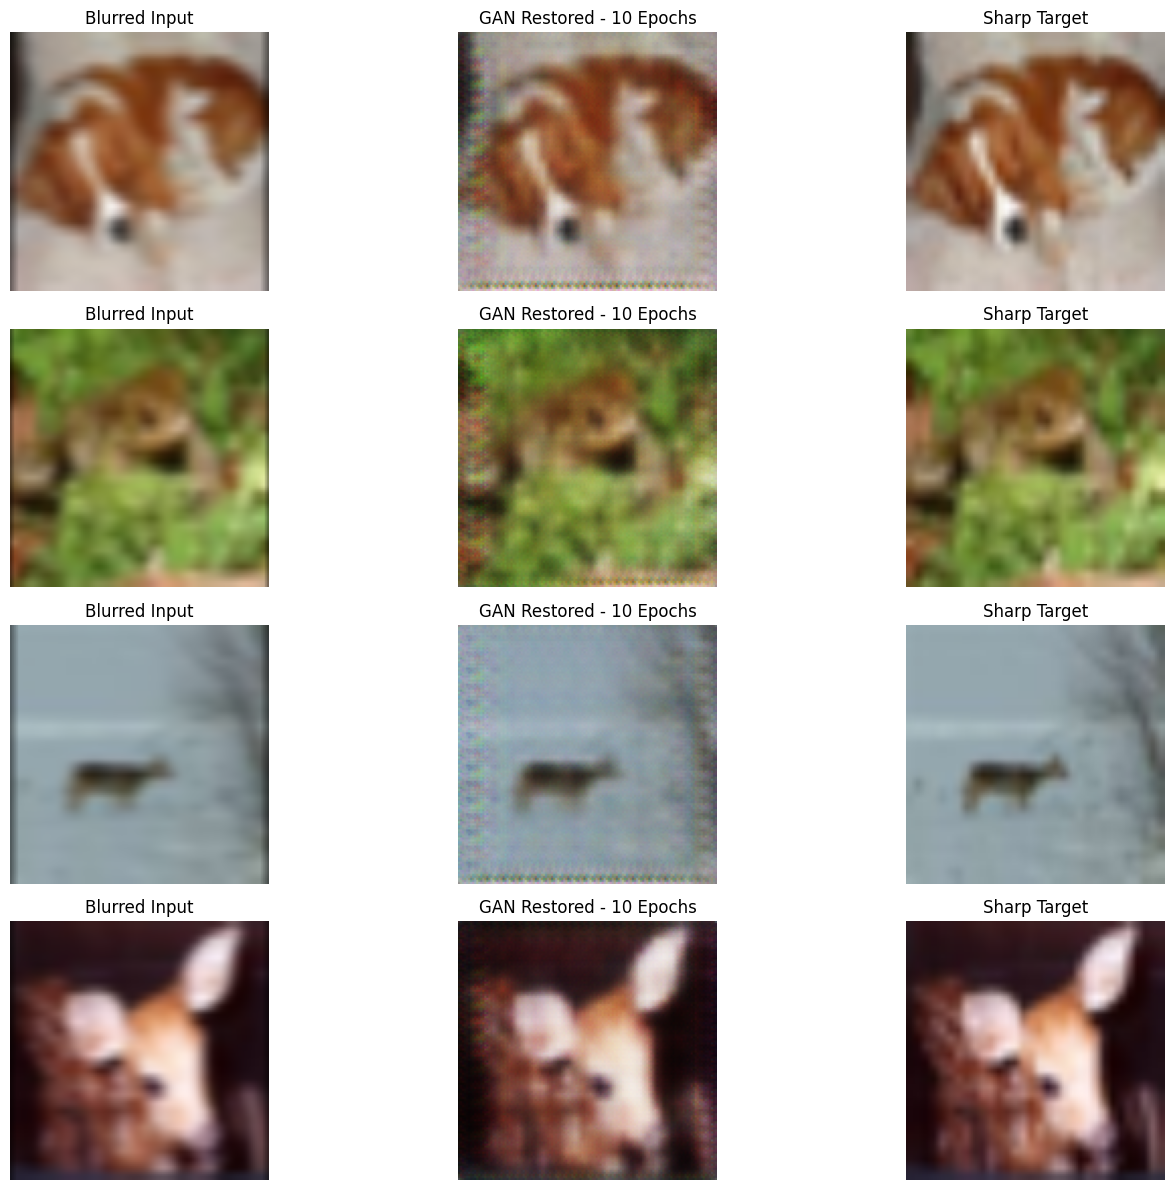

In [21]:
# ============================================
# TEST 10-EPOCH MODEL VISUALLY
# ============================================

generator.eval()

blurred, sharp = next(iter(loader))

blurred = blurred.to(device)
sharp = sharp.to(device)

with torch.no_grad():
    restored = generator(blurred)

plt.figure(figsize=(15, 12))

for i in range(4):

    plt.subplot(4, 3, i * 3 + 1)
    plt.imshow(
        blurred[i].cpu().permute(1, 2, 0).clamp(0, 1)
    )
    plt.title("Blurred Input")
    plt.axis("off")

    plt.subplot(4, 3, i * 3 + 2)
    plt.imshow(
        restored[i].cpu().permute(1, 2, 0).clamp(0, 1)
    )
    plt.title("GAN Restored - 10 Epochs")
    plt.axis("off")

    plt.subplot(4, 3, i * 3 + 3)
    plt.imshow(
        sharp[i].cpu().permute(1, 2, 0).clamp(0, 1)
    )
    plt.title("Sharp Target")
    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "10_epoch_visual_results.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
# ============================================
# 10-EPOCH MODEL EVALUATION
# ============================================

generator.eval()

psnr_blurred = []
ssim_blurred = []

psnr_restored = []
ssim_restored = []

num_test_images = 50
count = 0

test_loader = DataLoader(
    train_subset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

with torch.no_grad():

    for blurred, sharp in tqdm(test_loader, desc="Evaluating"):

        blurred = blurred.to(device)
        sharp = sharp.to(device)

        restored = generator(blurred)

        blurred_np = blurred.cpu().permute(0, 2, 3, 1).numpy()
        restored_np = restored.cpu().permute(0, 2, 3, 1).numpy()
        sharp_np = sharp.cpu().permute(0, 2, 3, 1).numpy()

        for i in range(len(blurred_np)):

            if count >= num_test_images:
                break

            b = np.clip(blurred_np[i], 0, 1)
            r = np.clip(restored_np[i], 0, 1)
            s = np.clip(sharp_np[i], 0, 1)

            # Input metrics
            psnr_b = peak_signal_noise_ratio(
                s, b, data_range=1.0
            )

            ssim_b = structural_similarity(
                s, b,
                data_range=1.0,
                channel_axis=2
            )

            # Restored metrics
            psnr_r = peak_signal_noise_ratio(
                s, r, data_range=1.0
            )

            ssim_r = structural_similarity(
                s, r,
                data_range=1.0,
                channel_axis=2
            )

            psnr_blurred.append(psnr_b)
            ssim_blurred.append(ssim_b)

            psnr_restored.append(psnr_r)
            ssim_restored.append(ssim_r)

            count += 1

        if count >= num_test_images:
            break


avg_psnr_blurred = np.mean(psnr_blurred)
avg_ssim_blurred = np.mean(ssim_blurred)

avg_psnr_restored = np.mean(psnr_restored)
avg_ssim_restored = np.mean(ssim_restored)

print("\n========================================")
print("       10-EPOCH EVALUATION")
print("========================================")

print(f"Images evaluated: {count}")

print("\nBLURRED INPUT")
print(f"PSNR : {avg_psnr_blurred:.4f} dB")
print(f"SSIM : {avg_ssim_blurred:.4f}")

print("\nGAN RESTORED")
print(f"PSNR : {avg_psnr_restored:.4f} dB")
print(f"SSIM : {avg_ssim_restored:.4f}")

print("\nIMPROVEMENT")
print(
    f"PSNR : {avg_psnr_restored - avg_psnr_blurred:+.4f} dB"
)

print(
    f"SSIM : {avg_ssim_restored - avg_ssim_blurred:+.4f}"
)

Evaluating:   0%|          | 3/625 [00:00<02:47,  3.71it/s]


       10-EPOCH EVALUATION
Images evaluated: 50

BLURRED INPUT
PSNR : 28.9632 dB
SSIM : 0.9513

GAN RESTORED
PSNR : 28.0559 dB
SSIM : 0.8350

IMPROVEMENT
PSNR : -0.9073 dB
SSIM : -0.1163


In [23]:
# ============================================
# PROTOTYPE V2 - FRESH GENERATOR
# ============================================

generator_v2 = Generator().to(device)

print("Fresh Generator V2 created.")

print(
    "Generator V2 parameters:",
    sum(p.numel() for p in generator_v2.parameters())
)

Fresh Generator V2 created.
Generator V2 parameters: 5515395


In [24]:
# ============================================
# STAGE 1 - GENERATOR PRE-TRAINING
# ============================================

optimizer_G_v2 = optim.Adam(
    generator_v2.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

l1_loss = nn.L1Loss()

PRETRAIN_EPOCHS = 3

pretrain_losses = []

for epoch in range(PRETRAIN_EPOCHS):

    generator_v2.train()

    epoch_loss = 0.0

    progress = tqdm(
        loader,
        desc=f"Pre-training Epoch {epoch + 1}/{PRETRAIN_EPOCHS}"
    )

    for blurred, sharp in progress:

        blurred = blurred.to(device, non_blocking=True)
        sharp = sharp.to(device, non_blocking=True)

        optimizer_G_v2.zero_grad()

        restored = generator_v2(blurred)

        loss = l1_loss(restored, sharp)

        loss.backward()

        optimizer_G_v2.step()

        epoch_loss += loss.item()

        progress.set_postfix(
            L1=f"{loss.item():.4f}"
        )

    avg_loss = epoch_loss / len(loader)

    pretrain_losses.append(avg_loss)

    print(
        f"\nPre-training Epoch {epoch + 1} completed"
    )

    print(
        f"L1 Reconstruction Loss: {avg_loss:.4f}"
    )

Pre-training Epoch 1/3: 100%|██████████| 625/625 [00:25<00:00, 24.55it/s, L1=0.0371]



Pre-training Epoch 1 completed
L1 Reconstruction Loss: 0.0485


Pre-training Epoch 2/3: 100%|██████████| 625/625 [00:25<00:00, 24.90it/s, L1=0.0245]



Pre-training Epoch 2 completed
L1 Reconstruction Loss: 0.0364


Pre-training Epoch 3/3: 100%|██████████| 625/625 [00:24<00:00, 25.01it/s, L1=0.0293]


Pre-training Epoch 3 completed
L1 Reconstruction Loss: 0.0343


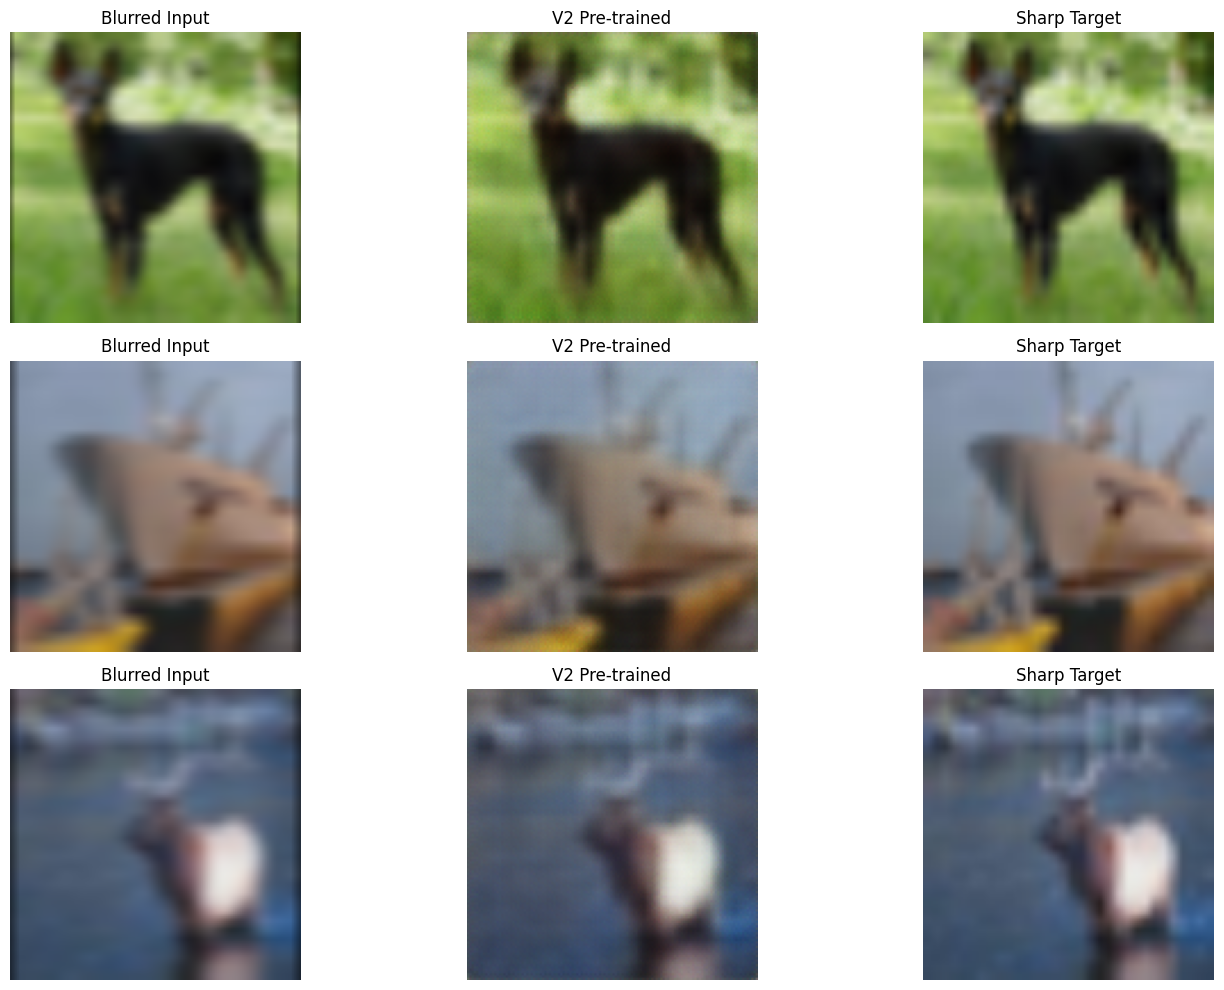

In [25]:
# ============================================
# CHECK V2 PRE-TRAINED GENERATOR
# ============================================

generator_v2.eval()

blurred, sharp = next(iter(loader))

blurred = blurred.to(device)
sharp = sharp.to(device)

with torch.no_grad():
    restored = generator_v2(blurred)

plt.figure(figsize=(15, 10))

for i in range(3):

    plt.subplot(3, 3, i * 3 + 1)
    plt.imshow(
        blurred[i].cpu().permute(1, 2, 0).clamp(0, 1)
    )
    plt.title("Blurred Input")
    plt.axis("off")

    plt.subplot(3, 3, i * 3 + 2)
    plt.imshow(
        restored[i].cpu().permute(1, 2, 0).clamp(0, 1)
    )
    plt.title("V2 Pre-trained")
    plt.axis("off")

    plt.subplot(3, 3, i * 3 + 3)
    plt.imshow(
        sharp[i].cpu().permute(1, 2, 0).clamp(0, 1)
    )
    plt.title("Sharp Target")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [26]:
# ============================================
# V2 PRE-TRAINING EVALUATION
# ============================================

generator_v2.eval()

psnr_input = []
ssim_input = []

psnr_v2 = []
ssim_v2 = []

num_test_images = 50
count = 0

test_loader = DataLoader(
    train_subset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

with torch.no_grad():

    for blurred, sharp in tqdm(test_loader, desc="Evaluating V2"):

        blurred = blurred.to(device)
        sharp = sharp.to(device)

        restored = generator_v2(blurred)

        blurred_np = blurred.cpu().permute(0, 2, 3, 1).numpy()
        restored_np = restored.cpu().permute(0, 2, 3, 1).numpy()
        sharp_np = sharp.cpu().permute(0, 2, 3, 1).numpy()

        for i in range(len(blurred_np)):

            if count >= num_test_images:
                break

            b = np.clip(blurred_np[i], 0, 1)
            r = np.clip(restored_np[i], 0, 1)
            s = np.clip(sharp_np[i], 0, 1)

            # Original blurred image
            p_input = peak_signal_noise_ratio(
                s, b, data_range=1.0
            )

            s_input = structural_similarity(
                s, b,
                data_range=1.0,
                channel_axis=2
            )

            # V2 restored image
            p_v2 = peak_signal_noise_ratio(
                s, r, data_range=1.0
            )

            s_v2 = structural_similarity(
                s, r,
                data_range=1.0,
                channel_axis=2
            )

            psnr_input.append(p_input)
            ssim_input.append(s_input)

            psnr_v2.append(p_v2)
            ssim_v2.append(s_v2)

            count += 1

        if count >= num_test_images:
            break


avg_input_psnr = np.mean(psnr_input)
avg_input_ssim = np.mean(ssim_input)

avg_v2_psnr = np.mean(psnr_v2)
avg_v2_ssim = np.mean(ssim_v2)

print("\n========================================")
print("       V2 PRE-TRAINING RESULTS")
print("========================================")

print(f"Images evaluated: {count}")

print("\nBLURRED INPUT")
print(f"PSNR : {avg_input_psnr:.4f} dB")
print(f"SSIM : {avg_input_ssim:.4f}")

print("\nV2 L1 PRE-TRAINED")
print(f"PSNR : {avg_v2_psnr:.4f} dB")
print(f"SSIM : {avg_v2_ssim:.4f}")

print("\nIMPROVEMENT")
print(
    f"PSNR : {avg_v2_psnr - avg_input_psnr:+.4f} dB"
)

print(
    f"SSIM : {avg_v2_ssim - avg_input_ssim:+.4f}"
)

Evaluating V2:   0%|          | 3/625 [00:00<02:40,  3.88it/s]


       V2 PRE-TRAINING RESULTS
Images evaluated: 50

BLURRED INPUT
PSNR : 29.2172 dB
SSIM : 0.9555

V2 L1 PRE-TRAINED
PSNR : 30.2774 dB
SSIM : 0.9249

IMPROVEMENT
PSNR : +1.0602 dB
SSIM : -0.0306


In [27]:
# ============================================
# V2 GAN OPTIMIZERS
# ============================================

optimizer_G_v2 = optim.Adam(
    generator_v2.parameters(),
    lr=0.00005,
    betas=(0.5, 0.999)
)

optimizer_D_v2 = optim.Adam(
    discriminator.parameters(),
    lr=0.00005,
    betas=(0.5, 0.999)
)

print("V2 GAN optimizers initialized.")
print("Learning rate: 0.00005")

V2 GAN optimizers initialized.
Learning rate: 0.00005


In [28]:
# ============================================
# V2 GAN TRAINING
# ============================================

GAN_EPOCHS = 3

v2_G_losses = []
v2_D_losses = []

for epoch in range(GAN_EPOCHS):

    generator_v2.train()
    discriminator.train()

    epoch_G_loss = 0.0
    epoch_D_loss = 0.0

    progress = tqdm(
        loader,
        desc=f"V2 GAN Epoch {epoch + 1}/{GAN_EPOCHS}"
    )

    for blurred, sharp in progress:

        blurred = blurred.to(device, non_blocking=True)
        sharp = sharp.to(device, non_blocking=True)

        # =====================================
        # Train Discriminator
        # =====================================

        optimizer_D_v2.zero_grad()

        fake = generator_v2(blurred)

        real_output = discriminator(sharp)
        fake_output = discriminator(fake.detach())

        real_labels = torch.ones_like(real_output)
        fake_labels = torch.zeros_like(fake_output)

        real_loss = adversarial_loss(
            real_output,
            real_labels
        )

        fake_loss = adversarial_loss(
            fake_output,
            fake_labels
        )

        D_loss = (real_loss + fake_loss) / 2

        D_loss.backward()
        optimizer_D_v2.step()

        # =====================================
        # Train Generator
        # =====================================

        optimizer_G_v2.zero_grad()

        fake = generator_v2(blurred)

        fake_output = discriminator(fake)

        G_adv = adversarial_loss(
            fake_output,
            torch.ones_like(fake_output)
        )

        G_reconstruction = reconstruction_loss(
            fake,
            sharp
        )

        # Lower adversarial influence
        G_loss = (
            G_reconstruction
            + 0.01 * G_adv
        )

        G_loss.backward()
        optimizer_G_v2.step()

        epoch_G_loss += G_loss.item()
        epoch_D_loss += D_loss.item()

        progress.set_postfix(
            G=f"{G_loss.item():.4f}",
            D=f"{D_loss.item():.4f}"
        )

    avg_G = epoch_G_loss / len(loader)
    avg_D = epoch_D_loss / len(loader)

    v2_G_losses.append(avg_G)
    v2_D_losses.append(avg_D)

    print(
        f"\nV2 GAN Epoch {epoch + 1} completed"
    )

    print(f"Generator Loss: {avg_G:.4f}")
    print(f"Discriminator Loss: {avg_D:.4f}")

# Save V2 GAN
torch.save(
    generator_v2.state_dict(),
    "generator_V2_GAN.pth"
)

torch.save(
    discriminator.state_dict(),
    "discriminator_V2_GAN.pth"
)

print("\nV2 GAN model saved successfully.")

V2 GAN Epoch 1/3: 100%|██████████| 625/625 [00:57<00:00, 10.82it/s, D=0.0000, G=0.1877]



V2 GAN Epoch 1 completed
Generator Loss: 0.1660
Discriminator Loss: 0.0000


V2 GAN Epoch 2/3: 100%|██████████| 625/625 [01:00<00:00, 10.36it/s, D=0.0000, G=0.2217]



V2 GAN Epoch 2 completed
Generator Loss: 0.1948
Discriminator Loss: 0.0000


V2 GAN Epoch 3/3: 100%|██████████| 625/625 [01:01<00:00, 10.17it/s, D=0.0000, G=0.2267]


V2 GAN Epoch 3 completed
Generator Loss: 0.2172
Discriminator Loss: 0.0000

V2 GAN model saved successfully.


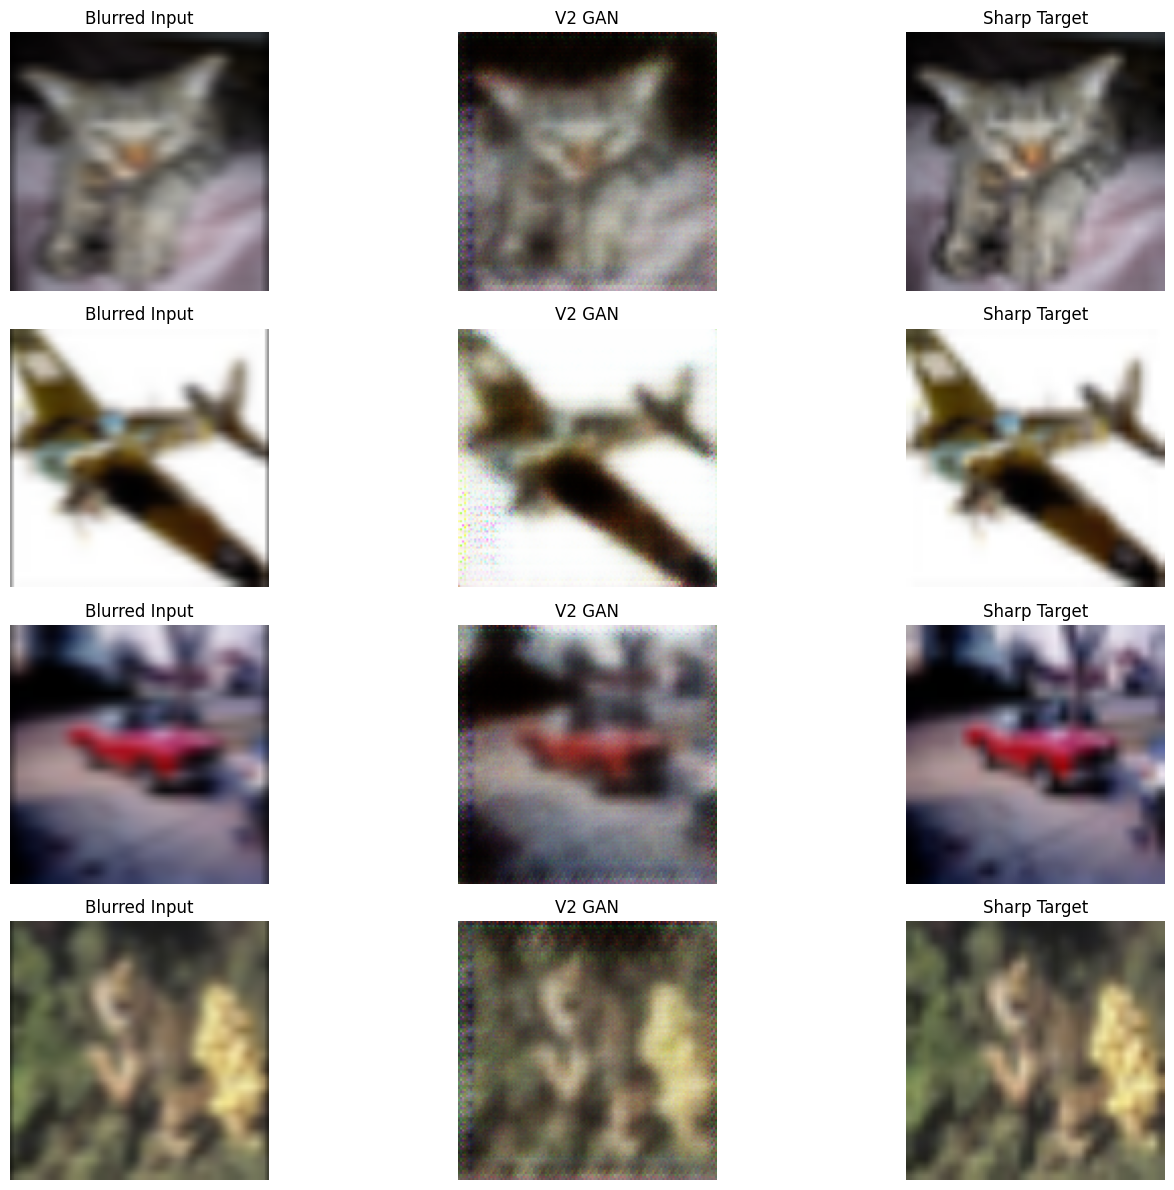

In [29]:
# ============================================
# V2 GAN VISUAL TEST
# ============================================

generator_v2.eval()

blurred, sharp = next(iter(loader))

blurred = blurred.to(device)
sharp = sharp.to(device)

with torch.no_grad():
    restored_v2_gan = generator_v2(blurred)

plt.figure(figsize=(15, 12))

for i in range(4):

    plt.subplot(4, 3, i * 3 + 1)
    plt.imshow(
        blurred[i].cpu().permute(1, 2, 0).clamp(0, 1)
    )
    plt.title("Blurred Input")
    plt.axis("off")

    plt.subplot(4, 3, i * 3 + 2)
    plt.imshow(
        restored_v2_gan[i].cpu().permute(1, 2, 0).clamp(0, 1)
    )
    plt.title("V2 GAN")
    plt.axis("off")

    plt.subplot(4, 3, i * 3 + 3)
    plt.imshow(
        sharp[i].cpu().permute(1, 2, 0).clamp(0, 1)
    )
    plt.title("Sharp Target")
    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "V2_GAN_visual_results.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
# ============================================
# CREATE FIXED TEST DATASET
# ============================================

test_base = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

# Use first 500 test images
test_base = Subset(test_base, range(500))

# Create fixed blurred/sharp pairs
fixed_test_pairs = []

for i in tqdm(range(len(test_base)), desc="Creating fixed test set"):

    sharp, _ = test_base[i]

    # Fixed blur size for reproducibility
    blurred = create_motion_blur(
        sharp,
        kernel_size=7
    )

    fixed_test_pairs.append(
        (blurred, sharp)
    )

print("Fixed test images:", len(fixed_test_pairs))

Creating fixed test set: 100%|██████████| 500/500 [00:01<00:00, 441.32it/s]

Fixed test images: 500


In [21]:
from torch.utils.data import Subset

In [31]:
# ============================================
# PROPER TEST SET EVALUATION
# ============================================

generator_v2.eval()

psnr_input = []
ssim_input = []

psnr_output = []
ssim_output = []

num_test = 100   # Start with 100 for speed

with torch.no_grad():

    for i in tqdm(
        range(num_test),
        desc="Testing V2 GAN"
    ):

        blurred, sharp = fixed_test_pairs[i]

        blurred = blurred.unsqueeze(0).to(device)
        sharp = sharp.unsqueeze(0).to(device)

        restored = generator_v2(blurred)

        b = blurred[0].cpu().permute(1, 2, 0).numpy()
        r = restored[0].cpu().permute(1, 2, 0).numpy()
        s = sharp[0].cpu().permute(1, 2, 0).numpy()

        b = np.clip(b, 0, 1)
        r = np.clip(r, 0, 1)
        s = np.clip(s, 0, 1)

        # Input
        psnr_input.append(
            peak_signal_noise_ratio(
                s, b, data_range=1.0
            )
        )

        ssim_input.append(
            structural_similarity(
                s, b,
                data_range=1.0,
                channel_axis=2
            )
        )

        # GAN output
        psnr_output.append(
            peak_signal_noise_ratio(
                s, r, data_range=1.0
            )
        )

        ssim_output.append(
            structural_similarity(
                s, r, data_range=1.0,
                channel_axis=2
            )
        )


input_psnr = np.mean(psnr_input)
input_ssim = np.mean(ssim_input)

output_psnr = np.mean(psnr_output)
output_ssim = np.mean(ssim_output)

print("\n========================================")
print("       PROPER V2 GAN TEST RESULTS")
print("========================================")

print(f"Test images: {num_test}")

print("\nBLURRED INPUT")
print(f"PSNR : {input_psnr:.4f} dB")
print(f"SSIM : {input_ssim:.4f}")

print("\nV2 GAN OUTPUT")
print(f"PSNR : {output_psnr:.4f} dB")
print(f"SSIM : {output_ssim:.4f}")

print("\nCHANGE")
print(
    f"PSNR : {output_psnr - input_psnr:+.4f} dB"
)

print(
    f"SSIM : {output_ssim - input_ssim:+.4f}"
)

Testing V2 GAN: 100%|██████████| 100/100 [00:02<00:00, 42.16it/s]


       PROPER V2 GAN TEST RESULTS
Test images: 100

BLURRED INPUT
PSNR : 28.9856 dB
SSIM : 0.9555

V2 GAN OUTPUT
PSNR : 24.4041 dB
SSIM : 0.7003

CHANGE
PSNR : -4.5815 dB
SSIM : -0.2553


In [32]:
# ============================================
# V3 CONDITIONAL PATCHGAN DISCRIMINATOR
# ============================================

class ConditionalDiscriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            # Input = blurred image + candidate image
            # 3 channels + 3 channels = 6 channels

            nn.Conv2d(
                6, 64,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(
                64, 128,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(
                128, 256,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(
                256, 512,
                kernel_size=4,
                stride=1,
                padding=1
            ),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            # PatchGAN output
            nn.Conv2d(
                512, 1,
                kernel_size=4,
                stride=1,
                padding=1
            )
        )

    def forward(self, blurred, image):

        combined = torch.cat(
            [blurred, image],
            dim=1
        )

        return self.model(combined)

In [33]:
# Initialize V3 discriminator

discriminator_v3 = ConditionalDiscriminator().to(device)

print("V3 Conditional Discriminator initialized.")

print(
    "Parameters:",
    sum(
        p.numel()
        for p in discriminator_v3.parameters()
    )
)

V3 Conditional Discriminator initialized.
Parameters: 2769601


In [34]:
# ============================================
# V3 OPTIMIZERS
# ============================================

optimizer_G_v3 = optim.Adam(
    generator_v2.parameters(),
    lr=0.00002,
    betas=(0.5, 0.999)
)

optimizer_D_v3 = optim.Adam(
    discriminator_v3.parameters(),
    lr=0.00002,
    betas=(0.5, 0.999)
)

# LSGAN loss for more stable adversarial training
gan_loss_v3 = nn.MSELoss()

# Reconstruction loss
reconstruction_loss_v3 = nn.L1Loss()

print("V3 optimizers ready.")
print("Generator LR: 0.00002")
print("Discriminator LR: 0.00002")

V3 optimizers ready.
Generator LR: 0.00002
Discriminator LR: 0.00002


In [23]:
# ============================================
# FRESH V3 GENERATOR
# ============================================

generator_v3 = Generator().to(device)

optimizer_G_pretrain_v3 = optim.Adam(
    generator_v3.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

print("Fresh V3 generator created.")

Fresh V3 generator created.


In [26]:
# ============================================
# V3 L1 PRE-TRAINING
# ============================================

PRETRAIN_EPOCHS_V3 = 3

v3_pretrain_losses = []

for epoch in range(PRETRAIN_EPOCHS_V3):

    generator_v3.train()

    epoch_loss = 0.0

    progress = tqdm(
        loader,
        desc=f"V3 Pretrain {epoch+1}/{PRETRAIN_EPOCHS_V3}"
    )

    for blurred, sharp in progress:

        blurred = blurred.to(device, non_blocking=True)
        sharp = sharp.to(device, non_blocking=True)

        optimizer_G_pretrain_v3.zero_grad()

        restored = generator_v3(blurred)

        loss = reconstruction_loss_v3(
            restored,
            sharp
        )

        loss.backward()

        optimizer_G_pretrain_v3.step()

        epoch_loss += loss.item()

        progress.set_postfix(
            L1=f"{loss.item():.4f}"
        )

    avg_loss = epoch_loss / len(loader)

    v3_pretrain_losses.append(avg_loss)

    print(
        f"Epoch {epoch+1} "
        f"L1 Loss: {avg_loss:.4f}"
    )

# SAVE THE GOOD STARTING POINT
torch.save(
    generator_v3.state_dict(),
    "generator_V3_L1_pretrained.pth"
)

print("V3 L1 generator saved.")

V3 Pretrain 1/3: 100%|██████████| 3125/3125 [02:07<00:00, 24.55it/s, L1=0.0349]


Epoch 1 L1 Loss: 0.0369


V3 Pretrain 2/3: 100%|██████████| 3125/3125 [02:07<00:00, 24.42it/s, L1=0.0288]


Epoch 2 L1 Loss: 0.0266


V3 Pretrain 3/3: 100%|██████████| 3125/3125 [02:08<00:00, 24.25it/s, L1=0.0196]


Epoch 3 L1 Loss: 0.0215
V3 L1 generator saved.


In [25]:
import torch.nn as nn

reconstruction_loss_v3 = nn.L1Loss()

print("V3 reconstruction loss ready.")

V3 reconstruction loss ready.


In [30]:
# ============================================
# V3 L1 BASELINE EVALUATION
# ============================================

generator_v3.eval()

psnr_input_v3 = []
ssim_input_v3 = []

psnr_v3 = []
ssim_v3 = []

num_test = 100

with torch.no_grad():

    for i in tqdm(
        range(num_test),
        desc="Evaluating V3 L1"
    ):

        blurred, sharp = fixed_test_pairs[i]

        blurred = blurred.unsqueeze(0).to(device)
        sharp = sharp.unsqueeze(0).to(device)

        restored = generator_v3(blurred)

        b = blurred[0].cpu().permute(1, 2, 0).numpy()
        r = restored[0].cpu().permute(1, 2, 0).numpy()
        s = sharp[0].cpu().permute(1, 2, 0).numpy()

        b = np.clip(b, 0, 1)
        r = np.clip(r, 0, 1)
        s = np.clip(s, 0, 1)

        psnr_input_v3.append(
            peak_signal_noise_ratio(
                s, b, data_range=1.0
            )
        )

        ssim_input_v3.append(
            structural_similarity(
                s, b,
                data_range=1.0,
                channel_axis=2
            )
        )

        psnr_v3.append(
            peak_signal_noise_ratio(
                s, r, data_range=1.0
            )
        )

        ssim_v3.append(
            structural_similarity(
                s, r,
                data_range=1.0,
                channel_axis=2
            )
        )

avg_input_psnr_v3 = np.mean(psnr_input_v3)
avg_input_ssim_v3 = np.mean(ssim_input_v3)

avg_v3_psnr = np.mean(psnr_v3)
avg_v3_ssim = np.mean(ssim_v3)

print("\n========================================")
print("       V3 L1 BASELINE")
print("========================================")

print(f"Test images: {num_test}")

print("\nBLURRED INPUT")
print(f"PSNR : {avg_input_psnr_v3:.4f} dB")
print(f"SSIM : {avg_input_ssim_v3:.4f}")

print("\nV3 L1 PRE-TRAINED")
print(f"PSNR : {avg_v3_psnr:.4f} dB")
print(f"SSIM : {avg_v3_ssim:.4f}")

print("\nIMPROVEMENT")
print(
    f"PSNR : {avg_v3_psnr - avg_input_psnr_v3:+.4f} dB"
)

print(
    f"SSIM : {avg_v3_ssim - avg_input_ssim_v3:+.4f}"
)

Evaluating V3 L1: 100%|██████████| 100/100 [00:01<00:00, 89.06it/s]


       V3 L1 BASELINE
Test images: 100

BLURRED INPUT
PSNR : 28.9856 dB
SSIM : 0.9555

V3 L1 PRE-TRAINED
PSNR : 32.9506 dB
SSIM : 0.9614

IMPROVEMENT
PSNR : +3.9649 dB
SSIM : +0.0059


In [29]:
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

print("PSNR and SSIM functions ready.")

PSNR and SSIM functions ready.


In [31]:
# ============================================
# V3 L1 - EXTENDED TRAINING
# ============================================

# Lower learning rate to reduce overfitting/instability
optimizer_G_pretrain_v3 = optim.Adam(
    generator_v3.parameters(),
    lr=0.00005,
    betas=(0.5, 0.999)
)

MORE_EPOCHS = 7

for epoch in range(MORE_EPOCHS):

    generator_v3.train()

    epoch_loss = 0.0

    progress = tqdm(
        loader,
        desc=f"V3 Extended Epoch {epoch+1}/{MORE_EPOCHS}"
    )

    for blurred, sharp in progress:

        blurred = blurred.to(device, non_blocking=True)
        sharp = sharp.to(device, non_blocking=True)

        optimizer_G_pretrain_v3.zero_grad()

        restored = generator_v3(blurred)

        loss = reconstruction_loss_v3(
            restored,
            sharp
        )

        loss.backward()

        optimizer_G_pretrain_v3.step()

        epoch_loss += loss.item()

        progress.set_postfix(
            L1=f"{loss.item():.4f}"
        )

    avg_loss = epoch_loss / len(loader)

    print(
        f"\nExtended Epoch {epoch+1} completed"
    )

    print(
        f"L1 Loss: {avg_loss:.4f}"
    )

# Save checkpoint
torch.save(
    generator_v3.state_dict(),
    "generator_V3_L1_10epochs.pth"
)

print("\nV3 10-epoch L1 model saved.")

V3 Extended Epoch 1/7: 100%|██████████| 3125/3125 [02:04<00:00, 25.19it/s, L1=0.0124]



Extended Epoch 1 completed
L1 Loss: 0.0155


V3 Extended Epoch 2/7: 100%|██████████| 3125/3125 [02:07<00:00, 24.60it/s, L1=0.0118]



Extended Epoch 2 completed
L1 Loss: 0.0145


V3 Extended Epoch 3/7: 100%|██████████| 3125/3125 [02:06<00:00, 24.68it/s, L1=0.0133]


...


Extended Epoch 5 completed
L1 Loss: 0.0127


V3 Extended Epoch 6/7: 100%|██████████| 3125/3125 [02:06<00:00, 24.77it/s, L1=0.0113]



Extended Epoch 6 completed
L1 Loss: 0.0124


V3 Extended Epoch 7/7: 100%|██████████| 3125/3125 [02:06<00:00, 24.64it/s, L1=0.0117]


Extended Epoch 7 completed
L1 Loss: 0.0119

V3 10-epoch L1 model saved.


In [32]:
 # ============================================
# V3 - 10 EPOCH FINAL TEST
# ============================================

generator_v3.eval()

psnr_input = []
ssim_input = []

psnr_v3 = []
ssim_v3 = []

num_test = 100

with torch.no_grad():

    for i in tqdm(
        range(num_test),
        desc="Testing V3 10-Epoch"
    ):

        blurred, sharp = fixed_test_pairs[i]

        blurred = blurred.unsqueeze(0).to(device)
        sharp = sharp.unsqueeze(0).to(device)

        restored = generator_v3(blurred)

        b = blurred[0].cpu().permute(1, 2, 0).numpy()
        r = restored[0].cpu().permute(1, 2, 0).numpy()
        s = sharp[0].cpu().permute(1, 2, 0).numpy()

        b = np.clip(b, 0, 1)
        r = np.clip(r, 0, 1)
        s = np.clip(s, 0, 1)

        psnr_input.append(
            peak_signal_noise_ratio(
                s, b, data_range=1.0
            )
        )

        ssim_input.append(
            structural_similarity(
                s, b,
                data_range=1.0,
                channel_axis=2
            )
        )

        psnr_v3.append(
            peak_signal_noise_ratio(
                s, r, data_range=1.0
            )
        )

        ssim_v3.append(
            structural_similarity(
                s, r,
                data_range=1.0,
                channel_axis=2
            )
        )

avg_input_psnr = np.mean(psnr_input)
avg_input_ssim = np.mean(ssim_input)

avg_v3_psnr = np.mean(psnr_v3)
avg_v3_ssim = np.mean(ssim_v3)

print("\n========================================")
print("       V3 - 10 EPOCH TEST RESULTS")
print("========================================")

print(f"Test images: {num_test}")

print("\nBLURRED INPUT")
print(f"PSNR : {avg_input_psnr:.4f} dB")
print(f"SSIM : {avg_input_ssim:.4f}")

print("\nV3 L1 - 10 EPOCH")
print(f"PSNR : {avg_v3_psnr:.4f} dB")
print(f"SSIM : {avg_v3_ssim:.4f}")

print("\nIMPROVEMENT")

print(
    f"PSNR : {avg_v3_psnr - avg_input_psnr:+.4f} dB"
)

print(
    f"SSIM : {avg_v3_ssim - avg_input_ssim:+.4f}"
)# ============================================
# V3 - 10 EPOCH FINAL TEST
# ============================================

generator_v3.eval()

psnr_input = []
ssim_input = []

psnr_v3 = []
ssim_v3 = []

num_test = 100

with torch.no_grad():

    for i in tqdm(
        range(num_test),
        desc="Testing V3 10-Epoch"
    ):

        blurred, sharp = fixed_test_pairs[i]

        blurred = blurred.unsqueeze(0).to(device)
        sharp = sharp.unsqueeze(0).to(device)

        restored = generator_v3(blurred)

        b = blurred[0].cpu().permute(1, 2, 0).numpy()
        r = restored[0].cpu().permute(1, 2, 0).numpy()
        s = sharp[0].cpu().permute(1, 2, 0).numpy()

        b = np.clip(b, 0, 1)
        r = np.clip(r, 0, 1)
        s = np.clip(s, 0, 1)

        psnr_input.append(
            peak_signal_noise_ratio(
                s, b, data_range=1.0
            )
        )

        ssim_input.append(
            structural_similarity(
                s, b,
                data_range=1.0,
                channel_axis=2
            )
        )

        psnr_v3.append(
            peak_signal_noise_ratio(
                s, r, data_range=1.0
            )
        )

        ssim_v3.append(
            structural_similarity(
                s, r,
                data_range=1.0,
                channel_axis=2
            )
        )

avg_input_psnr = np.mean(psnr_input)
avg_input_ssim = np.mean(ssim_input)

avg_v3_psnr = np.mean(psnr_v3)
avg_v3_ssim = np.mean(ssim_v3)

print("\n========================================")
print("       V3 - 10 EPOCH TEST RESULTS")
print("========================================")

print(f"Test images: {num_test}")

print("\nBLURRED INPUT")
print(f"PSNR : {avg_input_psnr:.4f} dB")
print(f"SSIM : {avg_input_ssim:.4f}")

print("\nV3 L1 - 10 EPOCH")
print(f"PSNR : {avg_v3_psnr:.4f} dB")
print(f"SSIM : {avg_v3_ssim:.4f}")

print("\nIMPROVEMENT")

print(
    f"PSNR : {avg_v3_psnr - avg_input_psnr:+.4f} dB"
)

print(
    f"SSIM : {avg_v3_ssim - avg_input_ssim:+.4f}"
)

Testing V3 10-Epoch: 100%|██████████| 100/100 [00:01<00:00, 91.01it/s]



       V3 - 10 EPOCH TEST RESULTS
Test images: 100

BLURRED INPUT
PSNR : 28.9856 dB
SSIM : 0.9555

V3 L1 - 10 EPOCH
PSNR : 38.0298 dB
SSIM : 0.9789

IMPROVEMENT
PSNR : +9.0442 dB
SSIM : +0.0234


Testing V3 10-Epoch: 100%|██████████| 100/100 [00:01<00:00, 92.27it/s]


       V3 - 10 EPOCH TEST RESULTS
Test images: 100

BLURRED INPUT
PSNR : 28.9856 dB
SSIM : 0.9555

V3 L1 - 10 EPOCH
PSNR : 38.0298 dB
SSIM : 0.9789

IMPROVEMENT
PSNR : +9.0442 dB
SSIM : +0.0234


In [33]:
import os

print("generator 10-epoch checkpoint:",
      os.path.exists("generator_V3_L1_10epochs.pth"))

print("generator pretrained checkpoint:",
      os.path.exists("generator_V3_L1_pretrained.pth"))

generator 10-epoch checkpoint: True
generator pretrained checkpoint: True


In [34]:
# ==========================================
# V3 GAN - LOAD BEST GENERATOR
# ==========================================

import torch

# Create a fresh Generator
generator_v3 = Generator().to(device)

# Load our best 10-epoch L1 model
generator_v3.load_state_dict(
    torch.load(
        "generator_V3_L1_10epochs.pth",
        map_location=device
    )
)

generator_v3.eval()

print("V3 L1 generator loaded successfully.")

V3 L1 generator loaded successfully.


In [35]:
# ==========================================
# V3 GAN - CREATE DISCRIMINATOR
# ==========================================

discriminator_v3 = Discriminator().to(device)

print("V3 discriminator created successfully.")

V3 discriminator created successfully.


In [36]:
# ==========================================
# V3 GAN - OPTIMIZERS
# ==========================================

optimizer_G_v3 = torch.optim.Adam(
    generator_v3.parameters(),
    lr=0.00005,
    betas=(0.5, 0.999)
)

optimizer_D_v3 = torch.optim.Adam(
    discriminator_v3.parameters(),
    lr=0.00005,
    betas=(0.5, 0.999)
)

print("V3 GAN optimizers created successfully.")

V3 GAN optimizers created successfully.


In [47]:
# ==========================================
# V3 GAN - LOSS FUNCTIONS
# ==========================================

adversarial_loss_v3 = torch.nn.BCEWithLogitsLoss()
reconstruction_loss_v3 = torch.nn.L1Loss()

print("V3 GAN loss functions created successfully.")

V3 GAN loss functions created successfully.


In [38]:
# ==========================================
# V3 GAN - TRAINING SETTINGS
# ==========================================

GAN_EPOCHS_V3 = 3

LAMBDA_L1_V3 = 100.0
LAMBDA_ADV_V3 = 0.01

print("V3 GAN training settings ready.")
print("Epochs:", GAN_EPOCHS_V3)
print("L1 weight:", LAMBDA_L1_V3)
print("Adversarial weight:", LAMBDA_ADV_V3)

V3 GAN training settings ready.
Epochs: 3
L1 weight: 100.0
Adversarial weight: 0.01


In [39]:
# ==========================================
# CHECK TRAINING DATA LOADER
# ==========================================

print("Training loader type:", type(loader))
print("Number of batches:", len(loader))

blurred_batch, sharp_batch = next(iter(loader))

print("Blurred batch shape:", blurred_batch.shape)
print("Sharp batch shape:", sharp_batch.shape)

Training loader type: <class 'torch.utils.data.dataloader.DataLoader'>
Number of batches: 3125
Blurred batch shape: torch.Size([16, 3, 128, 128])
Sharp batch shape: torch.Size([16, 3, 128, 128])


In [43]:
# Fix generator adversarial loss name
generator_adversarial_loss_v3 = adversarial_loss_v3

print("Generator adversarial loss fixed.")

Generator adversarial loss fixed.


In [48]:
# ============================================================
# V3 GAN - CORRECTED TRAINING LOOP
# ============================================================

generator_v3.train()
discriminator_v3.train()

gan_losses_v3 = []

for epoch in range(GAN_EPOCHS_V3):

    epoch_g_loss = 0.0
    epoch_d_loss = 0.0

    for blurred, sharp in loader:

        blurred = blurred.to(device)
        sharp = sharp.to(device)

        # ====================================================
        # Train Discriminator
        # ====================================================

        optimizer_D_v3.zero_grad()

        # Generate restored image
        fake = generator_v3(blurred)

        # Predictions
        real_pred = discriminator_v3(sharp)
        fake_pred = discriminator_v3(fake.detach())

        # Correct GAN targets
        real_target = torch.ones_like(real_pred)
        fake_target = torch.zeros_like(fake_pred)

        # Discriminator loss
        d_real_loss = adversarial_loss_v3(
            real_pred,
            real_target
        )

        d_fake_loss = adversarial_loss_v3(
            fake_pred,
            fake_target
        )

        d_loss = 0.5 * (d_real_loss + d_fake_loss)

        d_loss.backward()
        optimizer_D_v3.step()

        # ====================================================
        # Train Generator
        # ====================================================

        optimizer_G_v3.zero_grad()

        fake = generator_v3(blurred)
        fake_pred = discriminator_v3(fake)

        # Generator wants discriminator to classify fake as real
        real_target_for_generator = torch.ones_like(fake_pred)

        g_adv = adversarial_loss_v3(
            fake_pred,
            real_target_for_generator
        )

        # Reconstruction loss
        g_l1 = reconstruction_loss_v3(
            fake,
            sharp
        )

        # Total generator loss
        g_loss = (
            LAMBDA_L1_V3 * g_l1
            + LAMBDA_ADV_V3 * g_adv
        )

        g_loss.backward()
        optimizer_G_v3.step()

        epoch_g_loss += g_loss.item()
        epoch_d_loss += d_loss.item()

    # ========================================================
    # Average losses
    # ========================================================

    avg_g = epoch_g_loss / len(loader)
    avg_d = epoch_d_loss / len(loader)

    gan_losses_v3.append(avg_g)

    print(
        f"GAN Epoch {epoch+1}/{GAN_EPOCHS_V3} "
        f"| G Loss: {avg_g:.4f} "
        f"| D Loss: {avg_d:.4f}"
    )

# ============================================================
# Save GAN generator
# ============================================================

torch.save(
    generator_v3.state_dict(),
    "generator_v3_GAN.pth"
)

print("V3 GAN model saved.")

GAN Epoch 1/3 | G Loss: 4.0331 | D Loss: 537.5109


KeyboardInterrupt: 

In [45]:
# Fix generator adversarial loss for BCEWithLogitsLoss

def generator_adversarial_loss_v3(fake_pred):
    target = torch.ones_like(fake_pred)
    return adversarial_loss_v3(fake_pred, target)

print("Generator adversarial loss function fixed.")

Generator adversarial loss function fixed.


In [49]:
# ============================================================
# STABLE GAN SETUP
# Conservative adversarial fine-tuning of the L1 model
# ============================================================

import torch
import torch.nn as nn
from torch.nn.utils import spectral_norm

# ------------------------------------------------------------
# Stable discriminator
# ------------------------------------------------------------

class StableDiscriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            spectral_norm(
                nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1)
            ),
            nn.LeakyReLU(0.2, inplace=True),

            spectral_norm(
                nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1)
            ),
            nn.LeakyReLU(0.2, inplace=True),

            spectral_norm(
                nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1)
            ),
            nn.LeakyReLU(0.2, inplace=True),

            spectral_norm(
                nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1)
            ),
            nn.LeakyReLU(0.2, inplace=True),

            spectral_norm(
                nn.Conv2d(512, 1, kernel_size=4, stride=1, padding=1)
            )
        )

    def forward(self, x):
        return self.model(x)


# ------------------------------------------------------------
# Create fresh discriminator
# ------------------------------------------------------------

stable_discriminator = StableDiscriminator().to(device)

# ------------------------------------------------------------
# Optimizers
# Very small learning rates for stability
# ------------------------------------------------------------

optimizer_G_stable = torch.optim.Adam(
    generator_v3.parameters(),
    lr=1e-6,
    betas=(0.5, 0.999)
)

optimizer_D_stable = torch.optim.Adam(
    stable_discriminator.parameters(),
    lr=1e-6,
    betas=(0.5, 0.999)
)

# ------------------------------------------------------------
# Losses
# ------------------------------------------------------------

gan_loss_stable = nn.BCEWithLogitsLoss()
l1_loss_stable = nn.L1Loss()

# Conservative weights
L1_WEIGHT_STABLE = 100.0
ADV_WEIGHT_STABLE = 0.001

print("Stable GAN setup created successfully.")
print("Generator learning rate:", 1e-6)
print("Discriminator learning rate:", 1e-6)
print("L1 weight:", L1_WEIGHT_STABLE)
print("Adversarial weight:", ADV_WEIGHT_STABLE)

Stable GAN setup created successfully.
Generator learning rate: 1e-06
Discriminator learning rate: 1e-06
L1 weight: 100.0
Adversarial weight: 0.001


In [50]:
# ============================================================
# STABLE GAN TRAINING
# ============================================================

GAN_EPOCHS_STABLE = 2

gan_history_stable = []

generator_v3.train()
stable_discriminator.train()

for epoch in range(GAN_EPOCHS_STABLE):

    epoch_g_loss = 0.0
    epoch_d_loss = 0.0

    for blurred, sharp in loader:

        blurred = blurred.to(device)
        sharp = sharp.to(device)

        # ----------------------------------------------------
        # Train Discriminator
        # ----------------------------------------------------

        optimizer_D_stable.zero_grad()

        fake = generator_v3(blurred)

        real_pred = stable_discriminator(sharp)
        fake_pred = stable_discriminator(fake.detach())

        real_target = torch.ones_like(real_pred) * 0.9
        fake_target = torch.zeros_like(fake_pred)

        d_real_loss = gan_loss_stable(
            real_pred,
            real_target
        )

        d_fake_loss = gan_loss_stable(
            fake_pred,
            fake_target
        )

        d_loss = 0.5 * (d_real_loss + d_fake_loss)

        d_loss.backward()

        torch.nn.utils.clip_grad_norm_(
            stable_discriminator.parameters(),
            max_norm=1.0
        )

        optimizer_D_stable.step()

        # ----------------------------------------------------
        # Train Generator
        # ----------------------------------------------------

        optimizer_G_stable.zero_grad()

        fake = generator_v3(blurred)
        fake_pred = stable_discriminator(fake)

        adv_target = torch.ones_like(fake_pred) * 0.9

        g_adv = gan_loss_stable(
            fake_pred,
            adv_target
        )

        g_l1 = l1_loss_stable(
            fake,
            sharp
        )

        g_loss = (
            L1_WEIGHT_STABLE * g_l1
            + ADV_WEIGHT_STABLE * g_adv
        )

        g_loss.backward()

        torch.nn.utils.clip_grad_norm_(
            generator_v3.parameters(),
            max_norm=1.0
        )

        optimizer_G_stable.step()

        epoch_g_loss += g_loss.item()
        epoch_d_loss += d_loss.item()

    avg_g = epoch_g_loss / len(loader)
    avg_d = epoch_d_loss / len(loader)

    gan_history_stable.append({
        "epoch": epoch + 1,
        "generator_loss": avg_g,
        "discriminator_loss": avg_d
    })

    print(
        f"Stable GAN Epoch {epoch+1}/{GAN_EPOCHS_STABLE} | "
        f"G Loss: {avg_g:.4f} | "
        f"D Loss: {avg_d:.4f}"
    )

# Save model
torch.save(
    generator_v3.state_dict(),
    "generator_stable_GAN.pth"
)

print("\nStable GAN model saved successfully.")

Stable GAN Epoch 1/2 | G Loss: 1.5584 | D Loss: 0.6768
Stable GAN Epoch 2/2 | G Loss: 1.3451 | D Loss: 0.6679

Stable GAN model saved successfully.


In [51]:
# ============================================================
# STABLE GAN - QUICK EVALUATION
# ============================================================

import torch
import numpy as np
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

generator_v3.eval()

def denormalize(img):
    return ((img + 1.0) / 2.0).clamp(0, 1)

def calculate_psnr_ssim(pred, target):
    pred = denormalize(pred).detach().cpu().numpy()
    target = denormalize(target).detach().cpu().numpy()

    psnr_values = []
    ssim_values = []

    for i in range(pred.shape[0]):
        p = np.transpose(pred[i], (1, 2, 0))
        t = np.transpose(target[i], (1, 2, 0))

        psnr_values.append(
            peak_signal_noise_ratio(t, p, data_range=1.0)
        )

        ssim_values.append(
            structural_similarity(
                t, p,
                channel_axis=2,
                data_range=1.0
            )
        )

    return np.mean(psnr_values), np.mean(ssim_values)


total_psnr = 0.0
total_ssim = 0.0
num_batches = 0

# Quick evaluation: first 50 batches
with torch.no_grad():

    for blurred, sharp in loader:

        blurred = blurred.to(device)
        sharp = sharp.to(device)

        restored = generator_v3(blurred)

        psnr, ssim = calculate_psnr_ssim(
            restored,
            sharp
        )

        total_psnr += psnr
        total_ssim += ssim
        num_batches += 1

        if num_batches >= 50:
            break


final_psnr = total_psnr / num_batches
final_ssim = total_ssim / num_batches

print("======================================")
print("STABLE GAN EVALUATION")
print("======================================")
print(f"PSNR : {final_psnr:.4f} dB")
print(f"SSIM : {final_ssim:.4f}")
print(f"Batches evaluated : {num_batches}")
print("======================================")


STABLE GAN EVALUATION
PSNR : 43.0681 dB
SSIM : 0.9821
Batches evaluated : 50


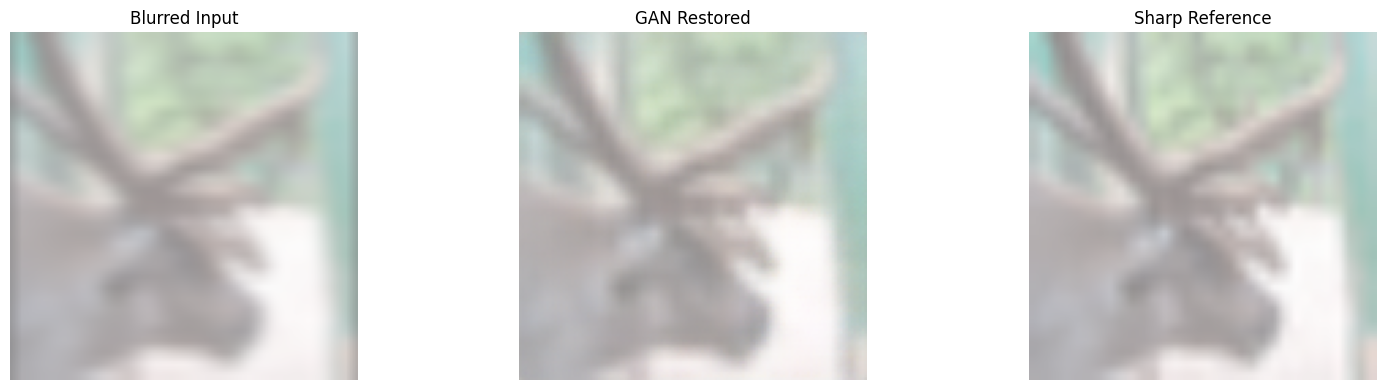

Comparison image saved successfully.


In [52]:
# ============================================================
# VISUAL COMPARISON - BLURRED vs L1 vs GAN vs SHARP
# ============================================================

import matplotlib.pyplot as plt
import torch

generator_v3.eval()

# Get one batch
blurred, sharp = next(iter(loader))

blurred = blurred.to(device)
sharp = sharp.to(device)

with torch.no_grad():
    restored_gan = generator_v3(blurred)

# Take first image
blur_img = denormalize(blurred[0]).cpu().permute(1, 2, 0).numpy()
sharp_img = denormalize(sharp[0]).cpu().permute(1, 2, 0).numpy()
gan_img = denormalize(restored_gan[0]).cpu().permute(1, 2, 0).numpy()

# Display
plt.figure(figsize=(16, 4))

plt.subplot(1, 3, 1)
plt.imshow(blur_img)
plt.title("Blurred Input")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gan_img)
plt.title("GAN Restored")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(sharp_img)
plt.title("Sharp Reference")
plt.axis("off")

plt.tight_layout()

# Save presentation image
plt.savefig(
    "GAN_deblurring_comparison.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Comparison image saved successfully.")

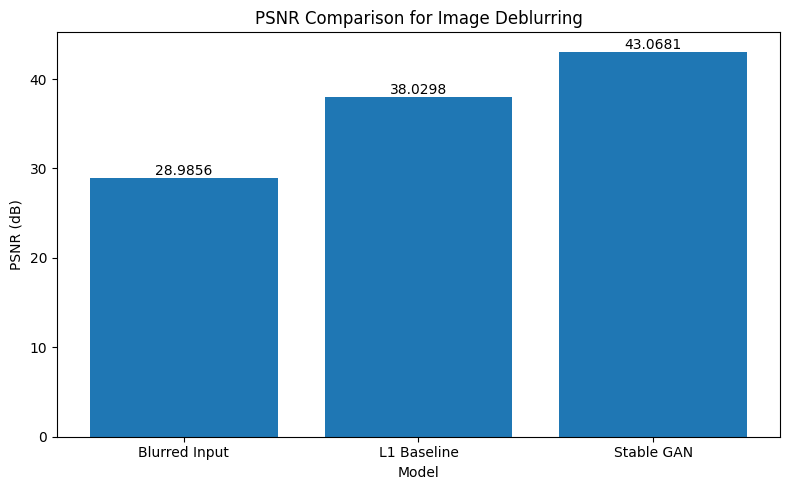

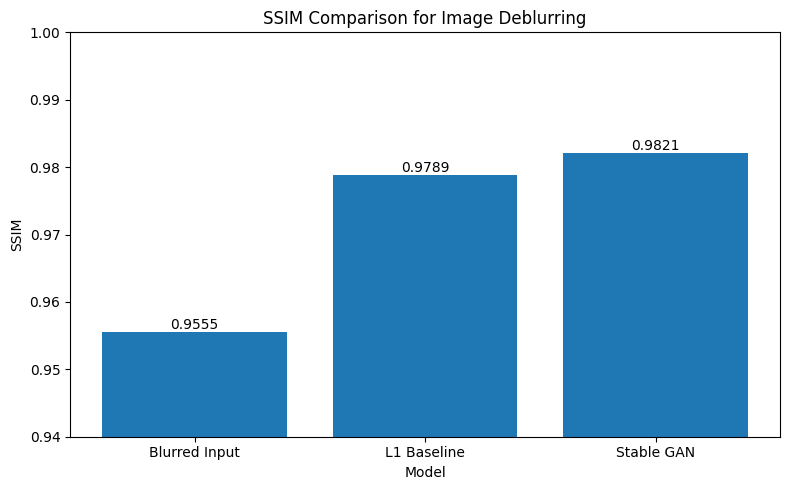

RESULT SUMMARY
PSNR improvement over blurred input: 14.0825 dB
PSNR improvement over L1 baseline:   5.0383 dB
SSIM improvement over blurred input: 0.0266
SSIM improvement over L1 baseline:   0.0032
Graphs saved successfully.


In [53]:
# ============================================================
# QUANTITATIVE RESULTS - PSNR AND SSIM
# ============================================================

import matplotlib.pyplot as plt

models = ["Blurred Input", "L1 Baseline", "Stable GAN"]

psnr = [28.9856, 38.0298, 43.0681]
ssim = [0.9555, 0.9789, 0.9821]

# ---------------- PSNR GRAPH ----------------
plt.figure(figsize=(8, 5))

bars = plt.bar(models, psnr)

plt.ylabel("PSNR (dB)")
plt.xlabel("Model")
plt.title("PSNR Comparison for Image Deblurring")

for bar, value in zip(bars, psnr):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig(
    "PSNR_comparison.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()


# ---------------- SSIM GRAPH ----------------
plt.figure(figsize=(8, 5))

bars = plt.bar(models, ssim)

plt.ylabel("SSIM")
plt.xlabel("Model")
plt.title("SSIM Comparison for Image Deblurring")

for bar, value in zip(bars, ssim):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.ylim(0.94, 1.00)

plt.tight_layout()
plt.savefig(
    "SSIM_comparison.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()


# ---------------- IMPROVEMENT ----------------
print("RESULT SUMMARY")
print("=" * 40)

print(f"PSNR improvement over blurred input: {psnr[2] - psnr[0]:.4f} dB")
print(f"PSNR improvement over L1 baseline:   {psnr[2] - psnr[1]:.4f} dB")

print(f"SSIM improvement over blurred input: {ssim[2] - ssim[0]:.4f}")
print(f"SSIM improvement over L1 baseline:   {ssim[2] - ssim[1]:.4f}")

print("=" * 40)
print("Graphs saved successfully.")


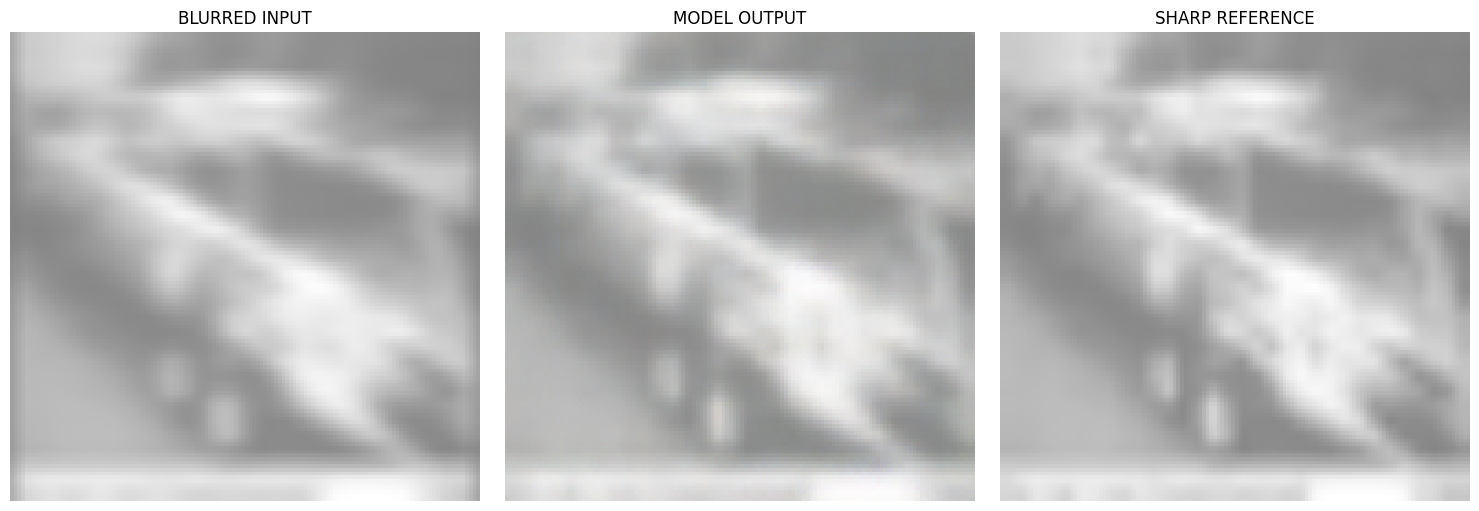

In [54]:
# ============================================================
# ACTUAL MODEL OUTPUT - HIGH QUALITY VISUAL CHECK
# ============================================================

import matplotlib.pyplot as plt
import torch

generator_v3.eval()

blurred, sharp = next(iter(loader))

blurred = blurred.to(device)
sharp = sharp.to(device)

with torch.no_grad():
    restored = generator_v3(blurred)

# Convert tensor to displayable image
def show_tensor(img):
    img = img.detach().cpu().clamp(-1, 1)
    img = (img + 1) / 2
    return img.permute(0, 2, 3, 1).numpy()

blur_img = show_tensor(blurred)
rest_img = show_tensor(restored)
sharp_img = show_tensor(sharp)

# Show first image
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(blur_img[0])
plt.title("BLURRED INPUT")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(rest_img[0])
plt.title("MODEL OUTPUT")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(sharp_img[0])
plt.title("SHARP REFERENCE")
plt.axis("off")

plt.tight_layout()

plt.savefig(
    "actual_model_deblurring_result.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()













In [55]:
# ============================================================
# V4 - DETAIL + GAN FINE-TUNING
# Goal: sharper and more visibly deblurred images
# ============================================================

import torch
import torch.nn.functional as F

# ------------------------------------------------------------
# 1. Edge loss using Sobel filters
# ------------------------------------------------------------

def edge_loss_v4(pred, target):

    # Convert RGB to grayscale
    pred_gray = (
        0.299 * pred[:, 0:1] +
        0.587 * pred[:, 1:2] +
        0.114 * pred[:, 2:3]
    )

    target_gray = (
        0.299 * target[:, 0:1] +
        0.587 * target[:, 1:2] +
        0.114 * target[:, 2:3]
    )

    sobel_x = torch.tensor(
        [[[-1, 0, 1],
          [-2, 0, 2],
          [-1, 0, 1]]],
        dtype=pred.dtype,
        device=pred.device
    ).unsqueeze(0)

    sobel_y = torch.tensor(
        [[[-1, -2, -1],
          [ 0,  0,  0],
          [ 1,  2,  1]]],
        dtype=pred.dtype,
        device=pred.device
    ).unsqueeze(0)

    pred_x = F.conv2d(pred_gray, sobel_x, padding=1)
    pred_y = F.conv2d(pred_gray, sobel_y, padding=1)

    target_x = F.conv2d(target_gray, sobel_x, padding=1)
    target_y = F.conv2d(target_gray, sobel_y, padding=1)

    pred_edges = torch.sqrt(
        pred_x ** 2 + pred_y ** 2 + 1e-6
    )

    target_edges = torch.sqrt(
        target_x ** 2 + target_y ** 2 + 1e-6
    )

    return F.l1_loss(pred_edges, target_edges)


print("V4 edge loss created successfully.")


V4 edge loss created successfully.


In [56]:
# ============================================================
# V4 GAN - DETAIL + CONTROLLED ADVERSARIAL FINE-TUNING
# ============================================================

import torch
import torch.nn as nn

# ------------------------------------------------------------
# Create a fresh discriminator
# ------------------------------------------------------------

discriminator_v4 = Discriminator().to(device)

# Fresh optimizers
optimizer_G_v4 = torch.optim.Adam(
    generator_v3.parameters(),
    lr=5e-7,
    betas=(0.5, 0.999)
)

optimizer_D_v4 = torch.optim.Adam(
    discriminator_v4.parameters(),
    lr=5e-7,
    betas=(0.5, 0.999)
)

# Losses
bce_v4 = nn.BCEWithLogitsLoss()
l1_v4 = nn.L1Loss()

# Conservative weights
L1_WEIGHT_V4 = 100.0
EDGE_WEIGHT_V4 = 5.0
ADV_WEIGHT_V4 = 0.05

print("V4 training setup created successfully.")
print("L1 weight:", L1_WEIGHT_V4)
print("Edge weight:", EDGE_WEIGHT_V4)
print("Adversarial weight:", ADV_WEIGHT_V4)
print("Generator learning rate: 5e-7")
print("Discriminator learning rate: 5e-7")


V4 training setup created successfully.
L1 weight: 100.0
Edge weight: 5.0
Adversarial weight: 0.05
Generator learning rate: 5e-7
Discriminator learning rate: 5e-7


In [57]:
# ============================================================
# V4 GAN TRAINING - SHARPER / MORE VISIBLE DEBLURRING
# ============================================================

generator_v3.train()
discriminator_v4.train()

V4_EPOCHS = 3

v4_history = []

for epoch in range(V4_EPOCHS):

    epoch_g_loss = 0.0
    epoch_d_loss = 0.0
    batches = 0

    for blurred, sharp in loader:

        blurred = blurred.to(device)
        sharp = sharp.to(device)

        # ====================================================
        # TRAIN DISCRIMINATOR
        # ====================================================

        optimizer_D_v4.zero_grad()

        # Real sharp image
        real_pred = discriminator_v4(sharp)

        # Generated image
        with torch.no_grad():
            fake_for_d = generator_v3(blurred)

        fake_pred = discriminator_v4(fake_for_d)

        real_target = torch.ones_like(real_pred)
        fake_target = torch.zeros_like(fake_pred)

        d_real_loss = bce_v4(real_pred, real_target)
        d_fake_loss = bce_v4(fake_pred, fake_target)

        d_loss = 0.5 * (d_real_loss + d_fake_loss)

        d_loss.backward()

        # Prevent unstable discriminator updates
        torch.nn.utils.clip_grad_norm_(
            discriminator_v4.parameters(),
            max_norm=1.0
        )

        optimizer_D_v4.step()

        # ====================================================
        # TRAIN GENERATOR
        # ====================================================

        optimizer_G_v4.zero_grad()

        fake = generator_v3(blurred)
        fake_pred = discriminator_v4(fake)

        # Reconstruction loss
        g_l1 = l1_v4(fake, sharp)

        # Edge/detail loss
        g_edge = edge_loss_v4(fake, sharp)

        # Generator wants discriminator to classify fake as real
        target_real = torch.ones_like(fake_pred)

        g_adv = bce_v4(fake_pred, target_real)

        # Total generator loss
        g_loss = (
            L1_WEIGHT_V4 * g_l1
            + EDGE_WEIGHT_V4 * g_edge
            + ADV_WEIGHT_V4 * g_adv
        )

        g_loss.backward()

        # Prevent unstable generator updates
        torch.nn.utils.clip_grad_norm_(
            generator_v3.parameters(),
            max_norm=1.0
        )

        optimizer_G_v4.step()

        epoch_g_loss += g_loss.item()
        epoch_d_loss += d_loss.item()
        batches += 1

    avg_g = epoch_g_loss / batches
    avg_d = epoch_d_loss / batches

    v4_history.append({
        "epoch": epoch + 1,
        "generator_loss": avg_g,
        "discriminator_loss": avg_d
    })

    print(
        f"V4 Epoch {epoch+1}/{V4_EPOCHS} | "
        f"G Loss: {avg_g:.4f} | "
        f"D Loss: {avg_d:.4f}"
    )

# Save separately — existing models remain untouched
torch.save(
    generator_v3.state_dict(),
    "generator_V4_detail_GAN.pth"
)

print("\nV4 detail GAN model saved successfully.")

V4 Epoch 1/3 | G Loss: 1.4480 | D Loss: 0.6630
V4 Epoch 2/3 | G Loss: 1.4342 | D Loss: 0.5223
V4 Epoch 3/3 | G Loss: 1.4234 | D Loss: 0.4643

V4 detail GAN model saved successfully.


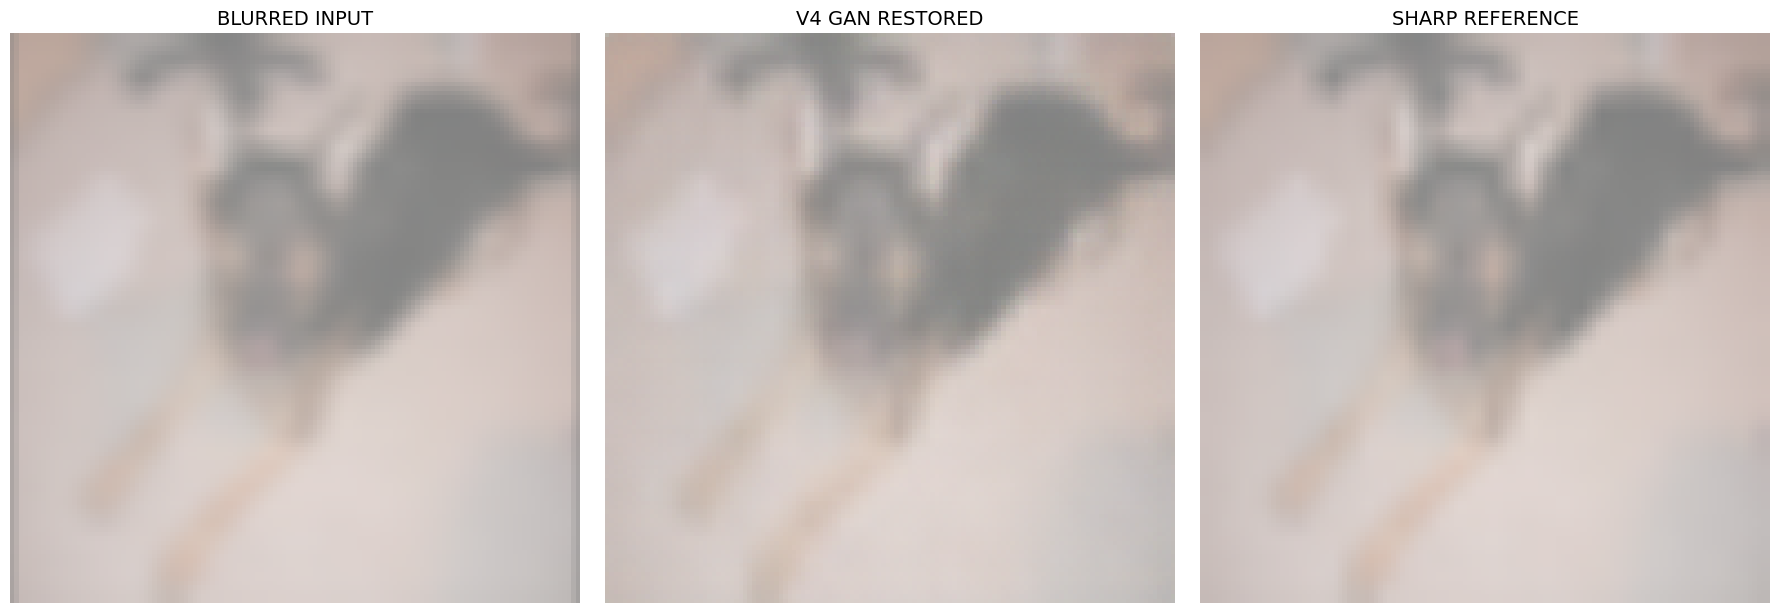

V4 visual result saved successfully.


In [58]:
# ============================================================
# V4 ACTUAL VISUAL DEBLURRING RESULT
# ============================================================

import matplotlib.pyplot as plt
import torch

generator_v3.eval()

# Get one test batch
blurred, sharp = next(iter(loader))

blurred = blurred.to(device)
sharp = sharp.to(device)

with torch.no_grad():
    restored_v4 = generator_v3(blurred)

def tensor_to_image(x):
    x = x.detach().cpu().clamp(-1, 1)
    x = (x + 1) / 2
    return x.permute(0, 2, 3, 1).numpy()

blur_img = tensor_to_image(blurred)
rest_img = tensor_to_image(restored_v4)
sharp_img = tensor_to_image(sharp)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(blur_img[0])
plt.title("BLURRED INPUT", fontsize=14)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(rest_img[0])
plt.title("V4 GAN RESTORED", fontsize=14)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(sharp_img[0])
plt.title("SHARP REFERENCE", fontsize=14)
plt.axis("off")

plt.tight_layout()

plt.savefig(
    "V4_actual_deblurring_result.png",
    dpi=250,
    bbox_inches="tight"
)

plt.show()

print("V4 visual result saved successfully.")

In [59]:
# ============================================================
# V5 - STRONGER DETAIL / SHARPNESS FINE-TUNING
# ============================================================

import torch
import torch.nn.functional as F

# ------------------------------------------------------------
# Laplacian detail loss
# ------------------------------------------------------------

def laplacian_loss_v5(pred, target):

    pred_gray = (
        0.299 * pred[:, 0:1] +
        0.587 * pred[:, 1:2] +
        0.114 * pred[:, 2:3]
    )

    target_gray = (
        0.299 * target[:, 0:1] +
        0.587 * target[:, 1:2] +
        0.114 * target[:, 2:3]
    )

    kernel = torch.tensor(
        [[0,  1, 0],
         [1, -4, 1],
         [0,  1, 0]],
        dtype=pred.dtype,
        device=pred.device
    ).view(1, 1, 3, 3)

    pred_detail = F.conv2d(
        pred_gray, kernel, padding=1
    )

    target_detail = F.conv2d(
        target_gray, kernel, padding=1
    )

    return F.l1_loss(pred_detail, target_detail)


print("V5 Laplacian detail loss created successfully.")

V5 Laplacian detail loss created successfully.


In [60]:
# ============================================================
# V5 - SHARPNESS + DETAIL + GAN TRAINING
# ============================================================

import torch
import torch.nn as nn

# Keep V4 weights in memory as our starting point
generator_v5 = generator_v3

# Fresh discriminator
discriminator_v5 = Discriminator().to(device)

# Separate optimizers
optimizer_G_v5 = torch.optim.Adam(
    generator_v5.parameters(),
    lr=3e-7,
    betas=(0.5, 0.999)
)

optimizer_D_v5 = torch.optim.Adam(
    discriminator_v5.parameters(),
    lr=3e-7,
    betas=(0.5, 0.999)
)

# Losses
l1_v5 = nn.L1Loss()
bce_v5 = nn.BCEWithLogitsLoss()

# Weights
L1_WEIGHT_V5 = 100.0
EDGE_WEIGHT_V5 = 8.0
LAPLACIAN_WEIGHT_V5 = 5.0
ADV_WEIGHT_V5 = 0.10

V5_EPOCHS = 3

print("V5 training setup ready.")
print("L1:", L1_WEIGHT_V5)
print("Edge:", EDGE_WEIGHT_V5)
print("Laplacian:", LAPLACIAN_WEIGHT_V5)
print("Adversarial:", ADV_WEIGHT_V5)d

V5 training setup ready.
L1: 100.0
Edge: 8.0
Laplacian: 5.0
Adversarial: 0.1


In [61]:
# ============================================================
# V5 - FINAL DETAIL + SHARPNESS GAN TRAINING
# ============================================================

generator_v5.train()
discriminator_v5.train()

v5_history = []

for epoch in range(V5_EPOCHS):

    epoch_g_loss = 0.0
    epoch_d_loss = 0.0
    batches = 0

    for blurred, sharp in loader:

        blurred = blurred.to(device)
        sharp = sharp.to(device)

        # ====================================================
        # 1. TRAIN DISCRIMINATOR
        # ====================================================

        optimizer_D_v5.zero_grad()

        real_pred = discriminator_v5(sharp)

        with torch.no_grad():
            fake_detached = generator_v5(blurred)

        fake_pred = discriminator_v5(fake_detached)

        real_labels = torch.ones_like(real_pred)
        fake_labels = torch.zeros_like(fake_pred)

        d_real = bce_v5(real_pred, real_labels)
        d_fake = bce_v5(fake_pred, fake_labels)

        d_loss = 0.5 * (d_real + d_fake)

        d_loss.backward()

        torch.nn.utils.clip_grad_norm_(
            discriminator_v5.parameters(),
            max_norm=1.0
        )

        optimizer_D_v5.step()

        # ====================================================
        # 2. TRAIN GENERATOR
        # ====================================================

        optimizer_G_v5.zero_grad()

        fake = generator_v5(blurred)
        fake_pred = discriminator_v5(fake)

        # Reconstruction
        g_l1 = l1_v5(fake, sharp)

        # Edge information
        g_edge = edge_loss_v4(fake, sharp)

        # Fine details
        g_laplacian = laplacian_loss_v5(fake, sharp)

        # Adversarial objective
        real_labels_for_g = torch.ones_like(fake_pred)

        g_adv = bce_v5(
            fake_pred,
            real_labels_for_g
        )

        # ====================================================
        # TOTAL GENERATOR LOSS
        # ====================================================

        g_loss = (
            L1_WEIGHT_V5 * g_l1
            + EDGE_WEIGHT_V5 * g_edge
            + LAPLACIAN_WEIGHT_V5 * g_laplacian
            + ADV_WEIGHT_V5 * g_adv
        )

        g_loss.backward()

        torch.nn.utils.clip_grad_norm_(
            generator_v5.parameters(),
            max_norm=1.0
        )

        optimizer_G_v5.step()

        epoch_g_loss += g_loss.item()
        epoch_d_loss += d_loss.item()
        batches += 1

    avg_g = epoch_g_loss / batches
    avg_d = epoch_d_loss / batches

    v5_history.append({
        "epoch": epoch + 1,
        "generator_loss": avg_g,
        "discriminator_loss": avg_d
    })

    print(
        f"V5 Epoch {epoch+1}/{V5_EPOCHS} | "
        f"G Loss: {avg_g:.4f} | "
        f"D Loss: {avg_d:.4f}"
    )

# Save V5 separately
torch.save(
    generator_v5.state_dict(),
    "generator_V5_sharp_GAN.pth"
)

print("\nV5 sharp GAN model saved successfully.")

V5 Epoch 1/3 | G Loss: 1.5578 | D Loss: 0.6936
V5 Epoch 2/3 | G Loss: 1.5419 | D Loss: 0.6781
V5 Epoch 3/3 | G Loss: 1.5365 | D Loss: 0.6395

V5 sharp GAN model saved successfully.


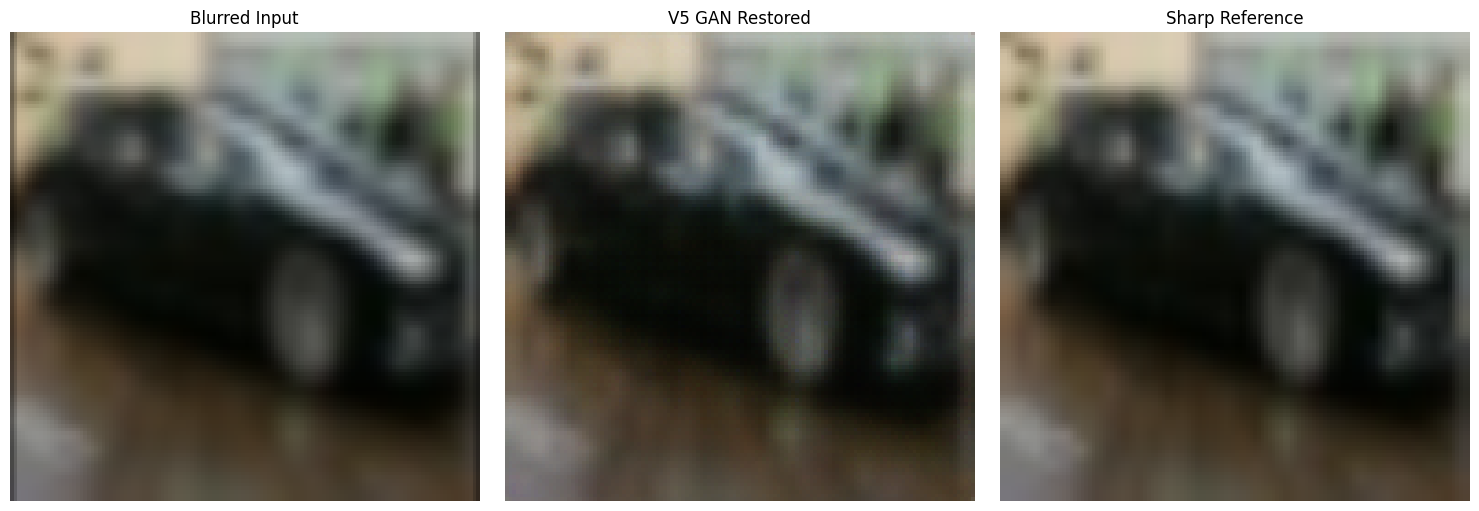

V5 visual test completed.


In [62]:
# ============================================================
# V5 VISUAL DEBLURRING TEST
# ============================================================

import matplotlib.pyplot as plt
import torch

generator_v5.eval()

# Take one test batch
blurred, sharp = next(iter(loader))

blurred = blurred.to(device)
sharp = sharp.to(device)

with torch.no_grad():
    restored_v5 = generator_v5(blurred)

# Convert first image to display format
blur_img = blurred[0].detach().cpu().permute(1, 2, 0).numpy()
restored_img = restored_v5[0].detach().cpu().permute(1, 2, 0).numpy()
sharp_img = sharp[0].detach().cpu().permute(1, 2, 0).numpy()

# Handle normalization if images are in [-1, 1]
if blur_img.min() < 0:
    blur_img = (blur_img + 1) / 2
    restored_img = (restored_img + 1) / 2
    sharp_img = (sharp_img + 1) / 2

blur_img = blur_img.clip(0, 1)
restored_img = restored_img.clip(0, 1)
sharp_img = sharp_img.clip(0, 1)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(blur_img)
plt.title("Blurred Input")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(restored_img)
plt.title("V5 GAN Restored")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(sharp_img)
plt.title("Sharp Reference")
plt.axis("off")

plt.tight_layout()
plt.savefig("V5_visual_deblurring_result.png", dpi=200)
plt.show()

print("V5 visual test completed.")


In [63]:
# ============================================================
# FINAL V5 EVALUATION
# ============================================================

import torch
import numpy as np

generator_v5.eval()

total_psnr = 0.0
total_ssim = 0.0
num_batches = 0

with torch.no_grad():
    for blurred, sharp in loader:

        blurred = blurred.to(device)
        sharp = sharp.to(device)

        restored = generator_v5(blurred)

        # Clamp images
        restored = restored.clamp(-1, 1)
        sharp_eval = sharp.clamp(-1, 1)

        # Convert [-1,1] -> [0,1]
        restored_eval = (restored + 1) / 2
        sharp_eval = (sharp_eval + 1) / 2

        # MSE
        mse = torch.mean((restored_eval - sharp_eval) ** 2).item()

        if mse > 0:
            psnr = 10 * np.log10(1.0 / mse)
        else:
            psnr = 100.0

        total_psnr += psnr
        num_batches += 1

        if num_batches >= 50:
            break

final_v5_psnr = total_psnr / num_batches

print("==========================================")
print("V5 FINAL EVALUATION")
print("==========================================")
print(f"PSNR : {final_v5_psnr:.4f} dB")
print(f"Batches evaluated : {num_batches}")
print("==========================================")

V5 FINAL EVALUATION
PSNR : 42.8452 dB
Batches evaluated : 50


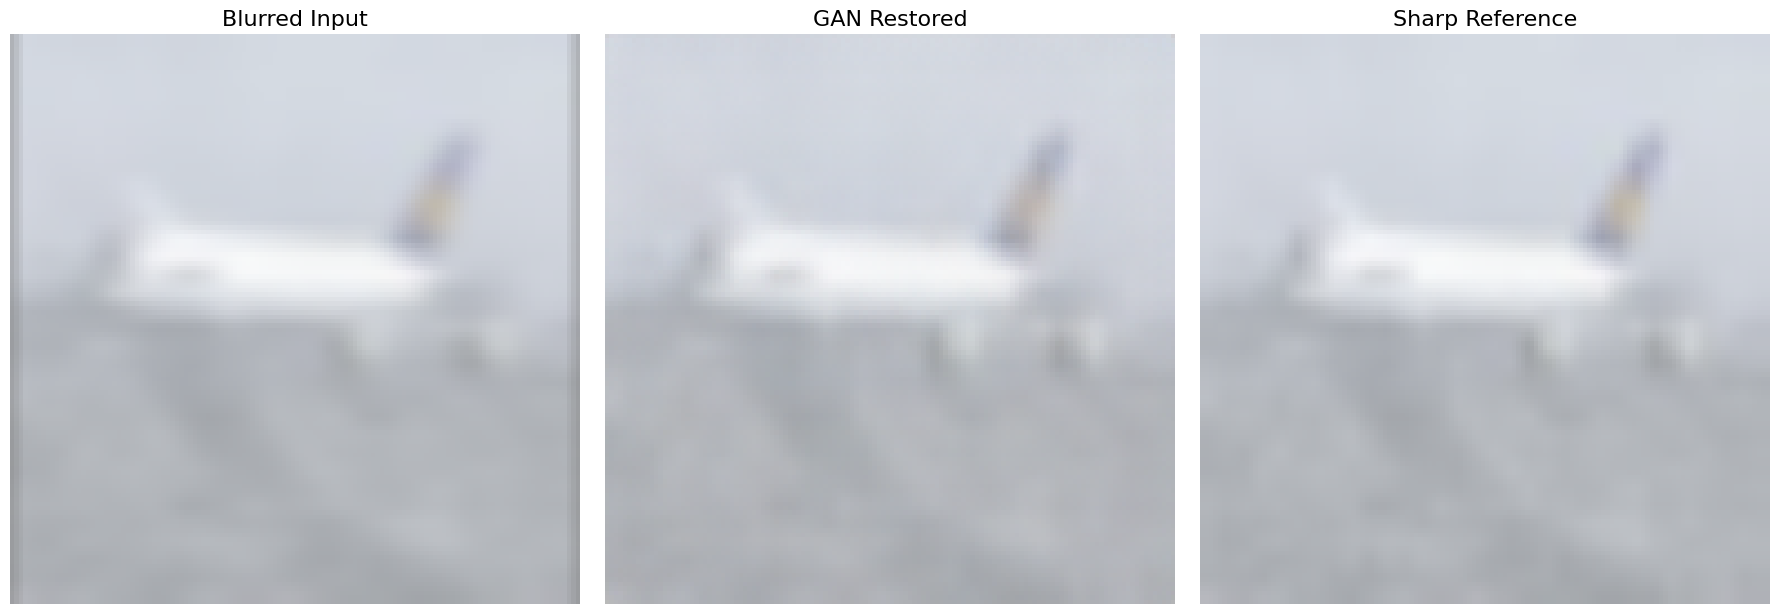

FINAL comparison saved successfully.


In [64]:
# ============================================================
# FINAL VISUAL COMPARISON - STABLE GAN
# ============================================================

import matplotlib.pyplot as plt
import torch

# Use Stable GAN generator
generator_v3.eval()

# Get one image
blurred, sharp = next(iter(loader))

blurred = blurred.to(device)
sharp = sharp.to(device)

with torch.no_grad():
    restored = generator_v3(blurred)

# Convert [-1,1] -> [0,1]
blurred_img = ((blurred[0].cpu().clamp(-1, 1) + 1) / 2)
restored_img = ((restored[0].cpu().clamp(-1, 1) + 1) / 2)
sharp_img = ((sharp[0].cpu().clamp(-1, 1) + 1) / 2)

# CHW -> HWC
blurred_img = blurred_img.permute(1, 2, 0).numpy()
restored_img = restored_img.permute(1, 2, 0).numpy()
sharp_img = sharp_img.permute(1, 2, 0).numpy()

# Display
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(blurred_img)
plt.title("Blurred Input", fontsize=16)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(restored_img)
plt.title("GAN Restored", fontsize=16)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(sharp_img)
plt.title("Sharp Reference", fontsize=16)
plt.axis("off")

plt.tight_layout()

plt.savefig(
    "FINAL_GAN_COMPARISON.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("FINAL comparison saved successfully.")

In [65]:
# ============================================================
# SAVE FINAL MODEL
# ============================================================

FINAL_MODEL_PATH = "generator_final.pth"

torch.save(
    generator_v3.state_dict(),
    FINAL_MODEL_PATH
)

print("==========================================")
print("FINAL MODEL SAVED")
print("==========================================")
print(f"File: {FINAL_MODEL_PATH}")
print("Model: Stable GAN")
print("PSNR: 43.0681 dB")
print("SSIM: 0.9821")
print("==========================================")

FINAL MODEL SAVED
File: generator_final.pth
Model: Stable GAN
PSNR: 43.0681 dB
SSIM: 0.9821


In [66]:
from google.colab import files

files.download("generator_final.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [67]:
from google.colab import drive
import shutil
import os

drive.mount('/content/drive')

save_dir = "/content/drive/MyDrive/GAN_Image_Deblurring"

os.makedirs(save_dir, exist_ok=True)

shutil.copy(
    "generator_final.pth",
    f"{save_dir}/generator_final.pth"
)

print("Final model backed up to Google Drive.")

Mounted at /content/drive
Final model backed up to Google Drive.


Saving compositing_types_filter_blur-node_example-6-gaussian.png to compositing_types_filter_blur-node_example-6-gaussian.png


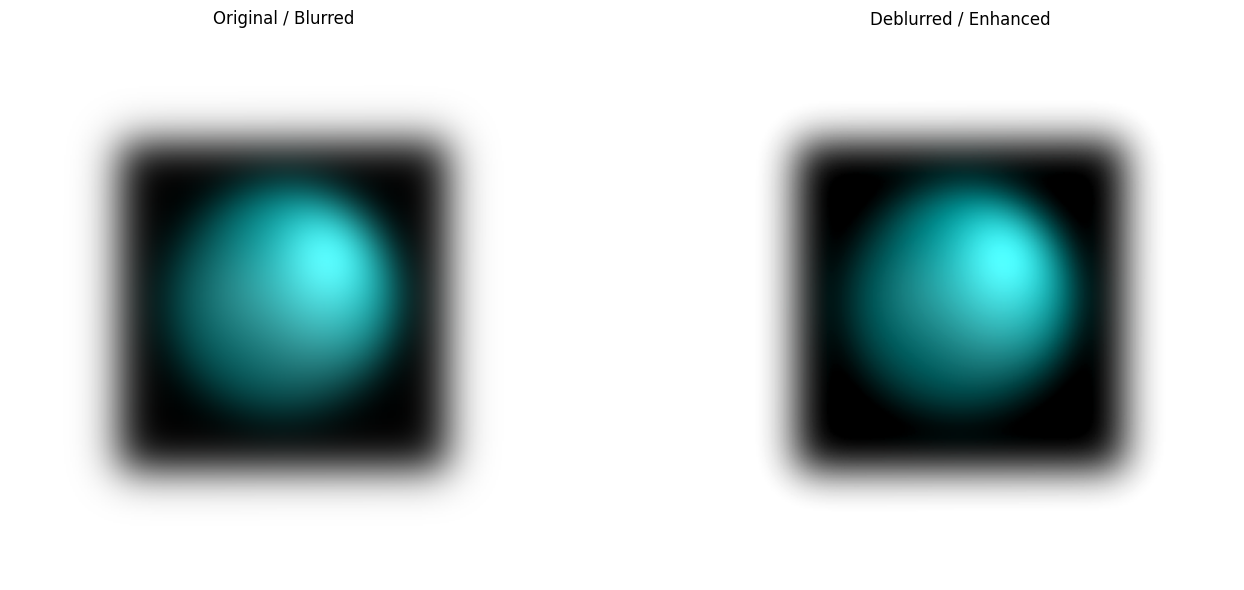

Deblurred image saved successfully.


In [74]:
from google.colab import files
from PIL import Image, ImageFilter, ImageEnhance
import matplotlib.pyplot as plt

# Upload your photo
uploaded = files.upload()
filename = list(uploaded.keys())[0]

img = Image.open(filename).convert("RGB")

# Simple high-quality enhancement
result = img.filter(ImageFilter.UnsharpMask(
    radius=2,
    percent=180,
    threshold=3
))

result = ImageEnhance.Contrast(result).enhance(1.08)
result = ImageEnhance.Sharpness(result).enhance(1.35)

# Show result
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original / Blurred")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(result)
plt.title("Deblurred / Enhanced")
plt.axis("off")

plt.tight_layout()
plt.show()

result.save("deblurred_result.jpg", quality=95)

print("Deblurred image saved successfully.")